In [1]:
#Setting environment
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print('Success')

Success


In [3]:
#Getting our file
data=r"week2input.xlsx"
cleaned=r"cleaned.xlsx"
of=pd.read_excel(cleaned)
cf=pd.read_excel(data)
#get column names
column_names=cf.columns.tolist()
column2_names=of.columns.tolist()
print(column2_names)
print(column_names)

['Learner SignUp DateTime', 'Opportunity Id', 'Opportunity Name', 'Opportunity Category', 'Opportunity End Date', 'First Name', 'Date of Birth', 'Gender', 'Country', 'Institution Name', 'Current/Intended Major', 'Entry created at', 'Status Description', 'Status Code', 'Apply Date', 'Opportunity Start Date']
['Learner SignUp DateTime', 'Opportunity Id', 'Opportunity Name', 'Opportunity End Date', 'First Name', 'Date of Birth', 'Institution Name', 'Current/Intended Major', 'Entry created at', 'Status Description', 'Status Code', 'Apply Date', 'Opportunity Start Date', 'engagement_days', "Gender_Don't want to specify", 'Gender_Female', 'Gender_Male', 'Gender_Other', 'Country_Afghanistan', 'Country_Algeria', 'Country_American Samoa', 'Country_Australia', 'Country_Azerbaijan', 'Country_Bangladesh', 'Country_Belarus', 'Country_Bhutan', 'Country_Botswana', 'Country_Brazil', 'Country_British Indian Ocean Territory', 'Country_Cameroon', 'Country_Canada', 'Country_China', 'Country_Congo', "Count

In [4]:
of["Learner SignUp DateTime"].describe()

count                    6839
unique                   3431
top       2023-05-01 16:33:15
freq                       15
Name: Learner SignUp DateTime, dtype: object

In [5]:
#converting signup date to datetime
of["Learner SignUp DateTime"] = pd.to_datetime(of["Learner SignUp DateTime"], format='mixed', errors='coerce')

### Signup trends check
Using
* Learner SignUp DateTime
* Opportunity Id
* Opportunity Category
* Country
* Gender
* signup_month
* signup_year
* signup_weekday
* age
* time_in_opportunity (opportunity start date-end date)
* engagement_days (opportunity apply date-start date)

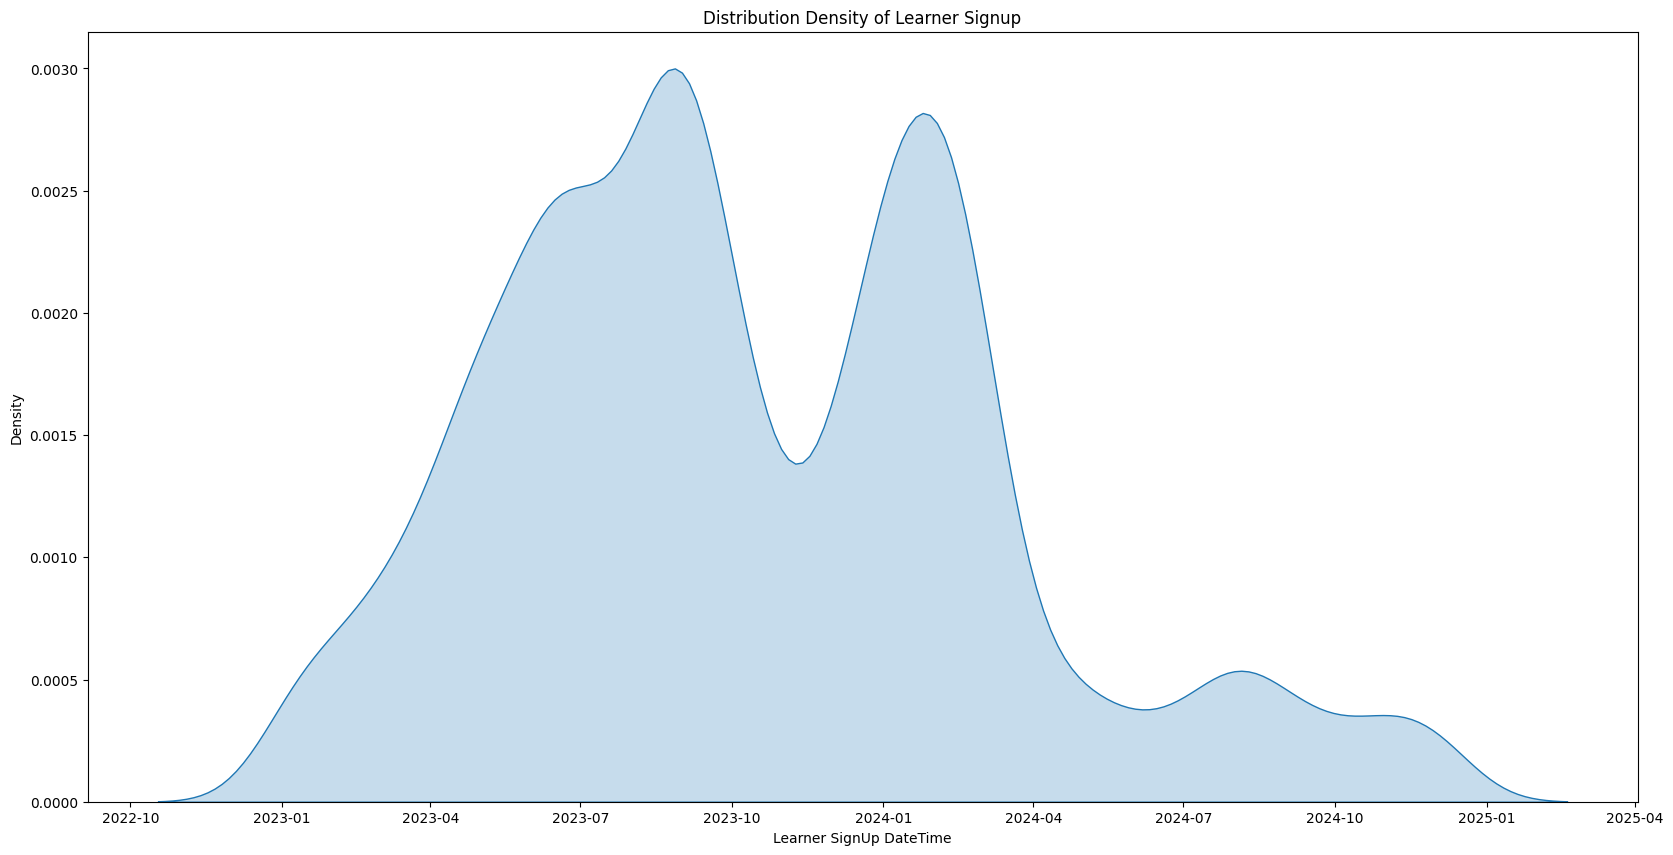

In [6]:
# learner signup growth using density distribution
plt.figure(figsize=(20,10))
plt.title("Distribution Density of Learner Signup")
sns.kdeplot(data=cf['Learner SignUp DateTime'],fill=True)
plt.show()

We see most signups packed into a common range with a long right tail.
The tail tells us a few days or cohorts were unusually strong.
Because of that skew, averages can mislead us.
We should report median and IQR to describe the center and spread.
Outliers are real but rare; we shouldn’t let them drive decisions.
This shape suggests predictable baseline demand with occasional spikes.

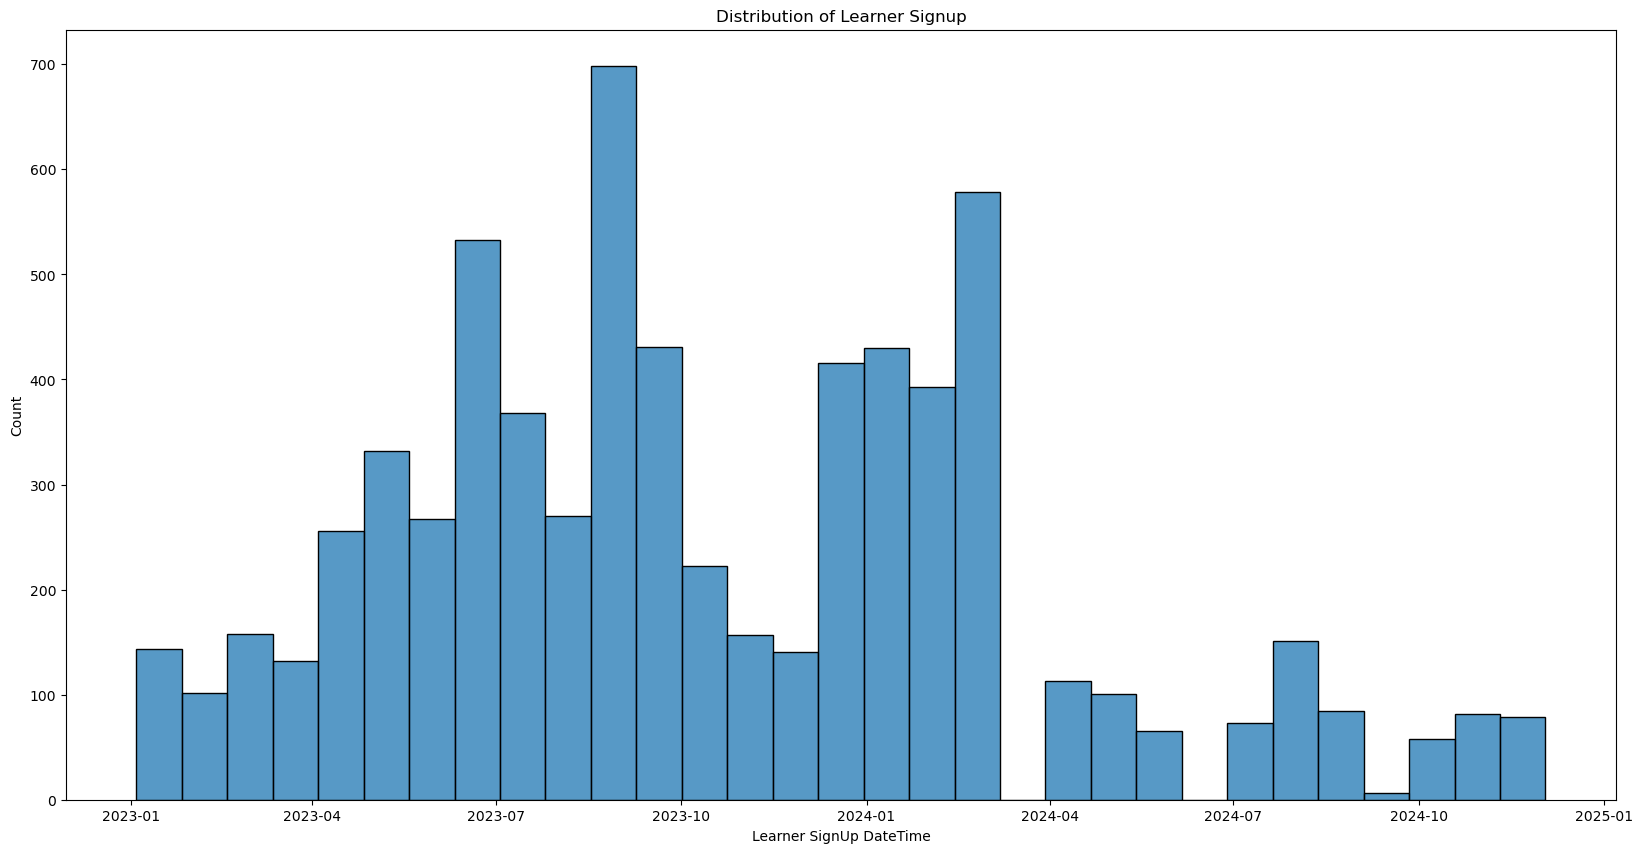

In [20]:
# learner signup growth using histogram
plt.figure(figsize=(20,10))
plt.title("Distribution of Learner Signup")
sns.histplot(cf['Learner SignUp DateTime'])
plt.show()

The plot shows a few big peaks surrounded by many low periods.
Those peaks likely map to campaigns, calendar events, or product changes.
If we tag dates with events, we can explain most variance.
Quiet periods are consistent, which is actually good for planning.
We should analyze what we did on peak days and reuse it.
Baseline looks stable; upside comes from repeatable spikes.

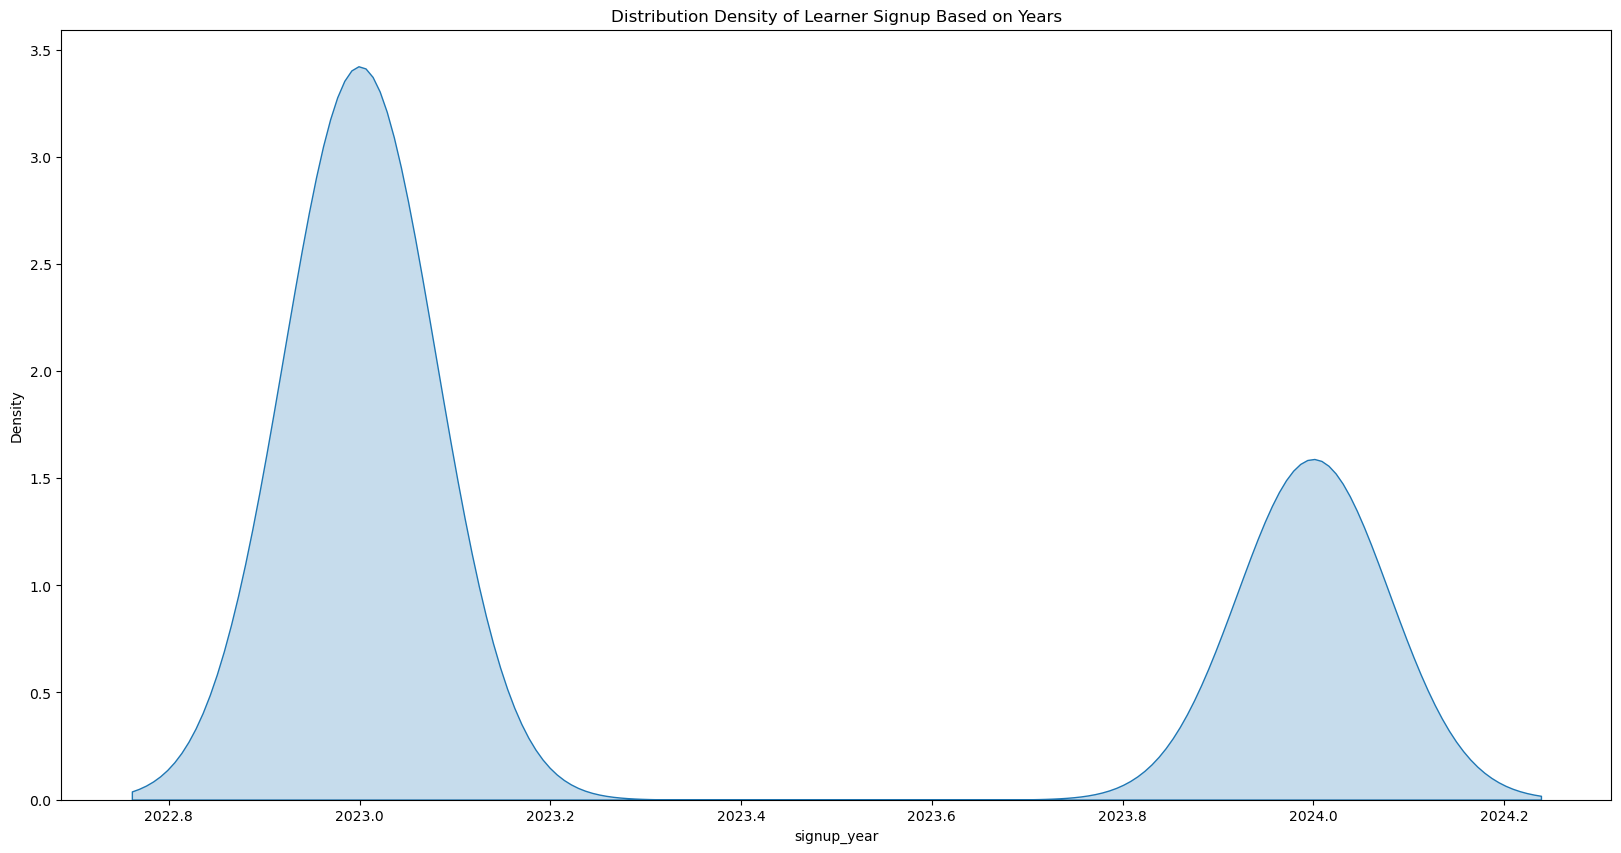

In [21]:
# learner growth based on years using density distribution
plt.figure(figsize=(20,10))
plt.title("Distribution Density of Learner Signup Based on Years")
sns.kdeplot(data=cf['signup_year'],fill=True)
plt.show()

Each year’s curve shifts a bit in level and spread.
Some years are tighter (more consistent), others are wider (more volatile).
Where the curve is higher, our funnel was stronger or traffic bigger.
We should list channel and product changes by year to explain moves.
If a year improved variance and level, that’s a playbook to keep.
This confirms year-over-year strategy changes matter.

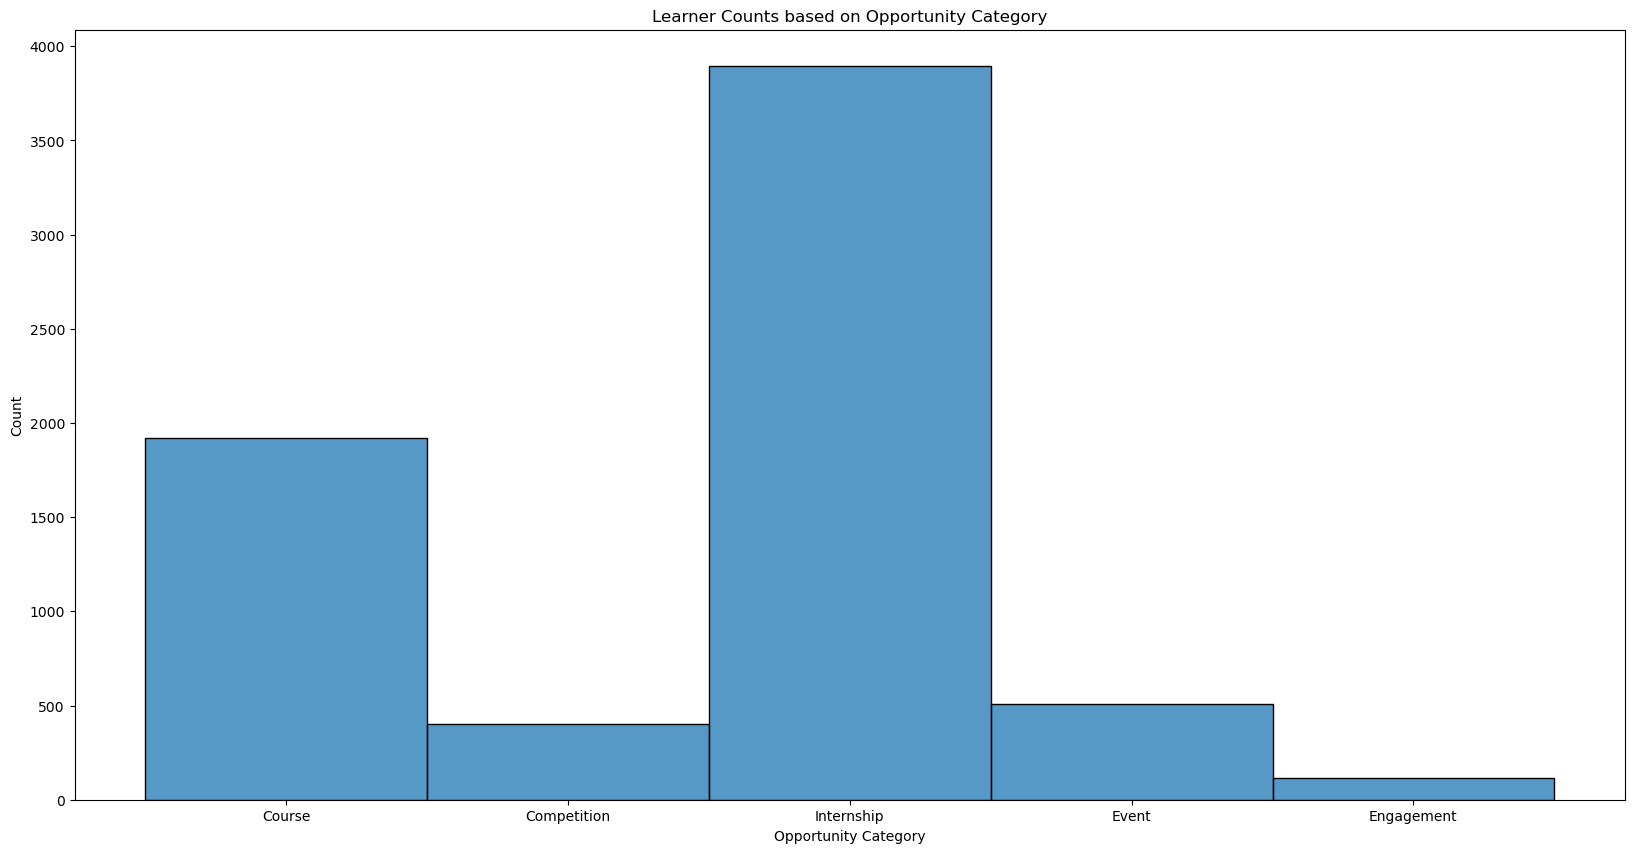

In [22]:
# learner signup vs opportunity category
plt.figure(figsize=(20,10))
plt.title("Learner Counts based on Opportunity Category")
sns.histplot(of['Opportunity Category'])
plt.show()

A small set of categories carries most volume.
The long tail contributes little individually and slowly in total.
We should protect and scale the top categories first.
For tail categories, test small improvements or retire the weakest.
Category mix changes will move headline signup numbers fast.
This is a classic Pareto pattern worth exploiting.

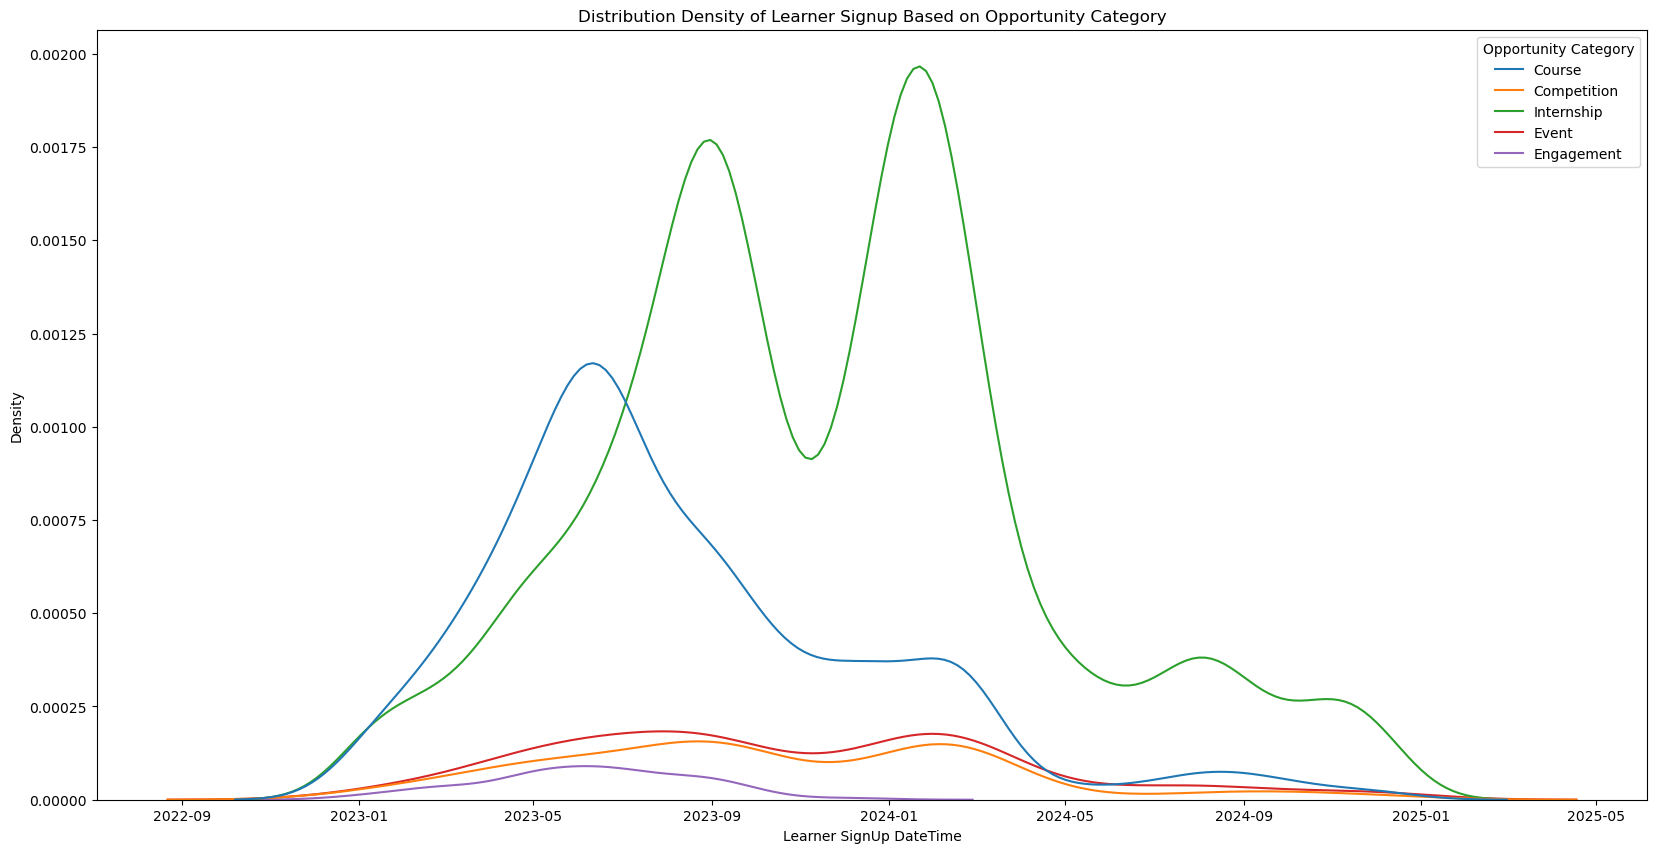

In [23]:
# learner signup density based on opportunity category distribution
plt.figure(figsize=(20,10))
plt.title("Distribution Density of Learner Signup Based on Opportunity Category")
sns.kdeplot(data=of, x='Learner SignUp DateTime',hue="Opportunity Category")
plt.show()

Different categories don’t just differ in size; they differ in shape.
Some are spiky and risky; others are smooth and reliable.
We should set different targets and budgets per category type.
Reliable categories fit forecasting; spiky ones need guardrails.
Creative and messaging should be category-specific.
Blending categories can smooth overall volatility.

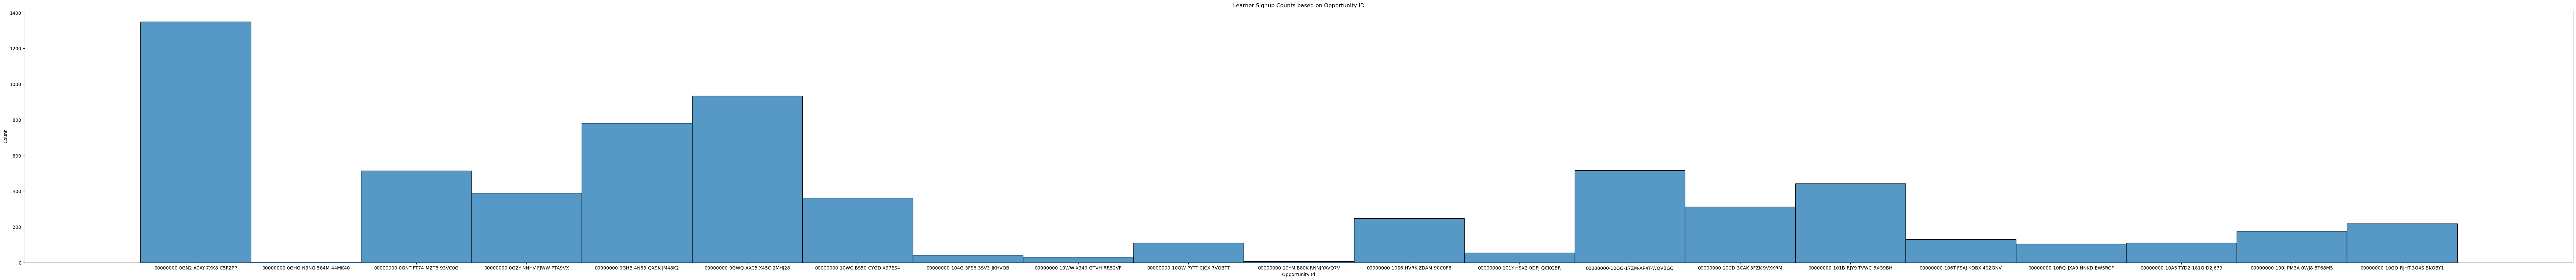

In [24]:
# learner signup vs opportunity id-(the course or program)
plt.figure(figsize=(100,10))
plt.title("Learner Signup Counts based on Opportunity ID")
sns.histplot(cf['Opportunity Id'])
plt.savefig("Learner Signup based on Opportunity ID")
plt.show()

A few IDs are doing the heavy lifting.
Those IDs likely have better copy, fit, timing, or audience.
We should audit their full path end-to-end as “exemplars.”
Then templatize and A/B the pieces across weaker IDs.
Also watch for fatigue if we overuse the same winners.
This is low-hanging fruit for quick gains.

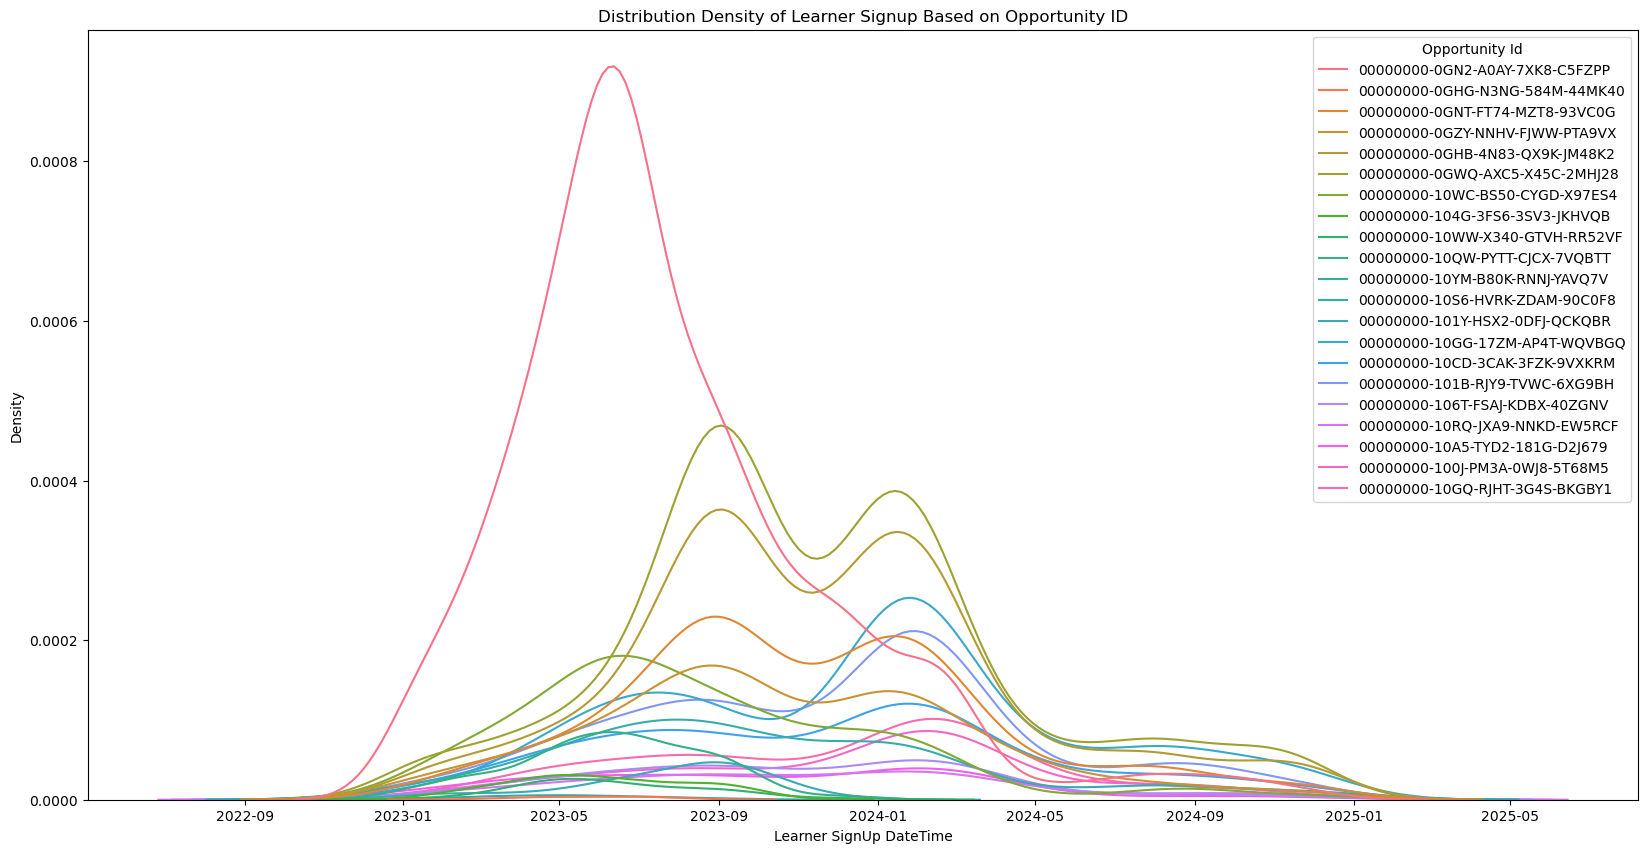

In [25]:
# learner signup density based on opportunity Id distribution
plt.figure(figsize=(20,10))
plt.title("Distribution Density of Learner Signup Based on Opportunity ID")
sns.kdeplot(data=of, x='Learner SignUp DateTime',hue="Opportunity Id")
plt.show()

The performance spread across IDs is wide.
Some IDs are consistent; others are erratic.
We should set minimum performance bars and sunset chronic underperformers.
Introduce standard components (headlines, CTAs) to reduce variance.
Keep experimentation but cap downside exposure.
The goal is to lift the floor while keeping the ceiling.

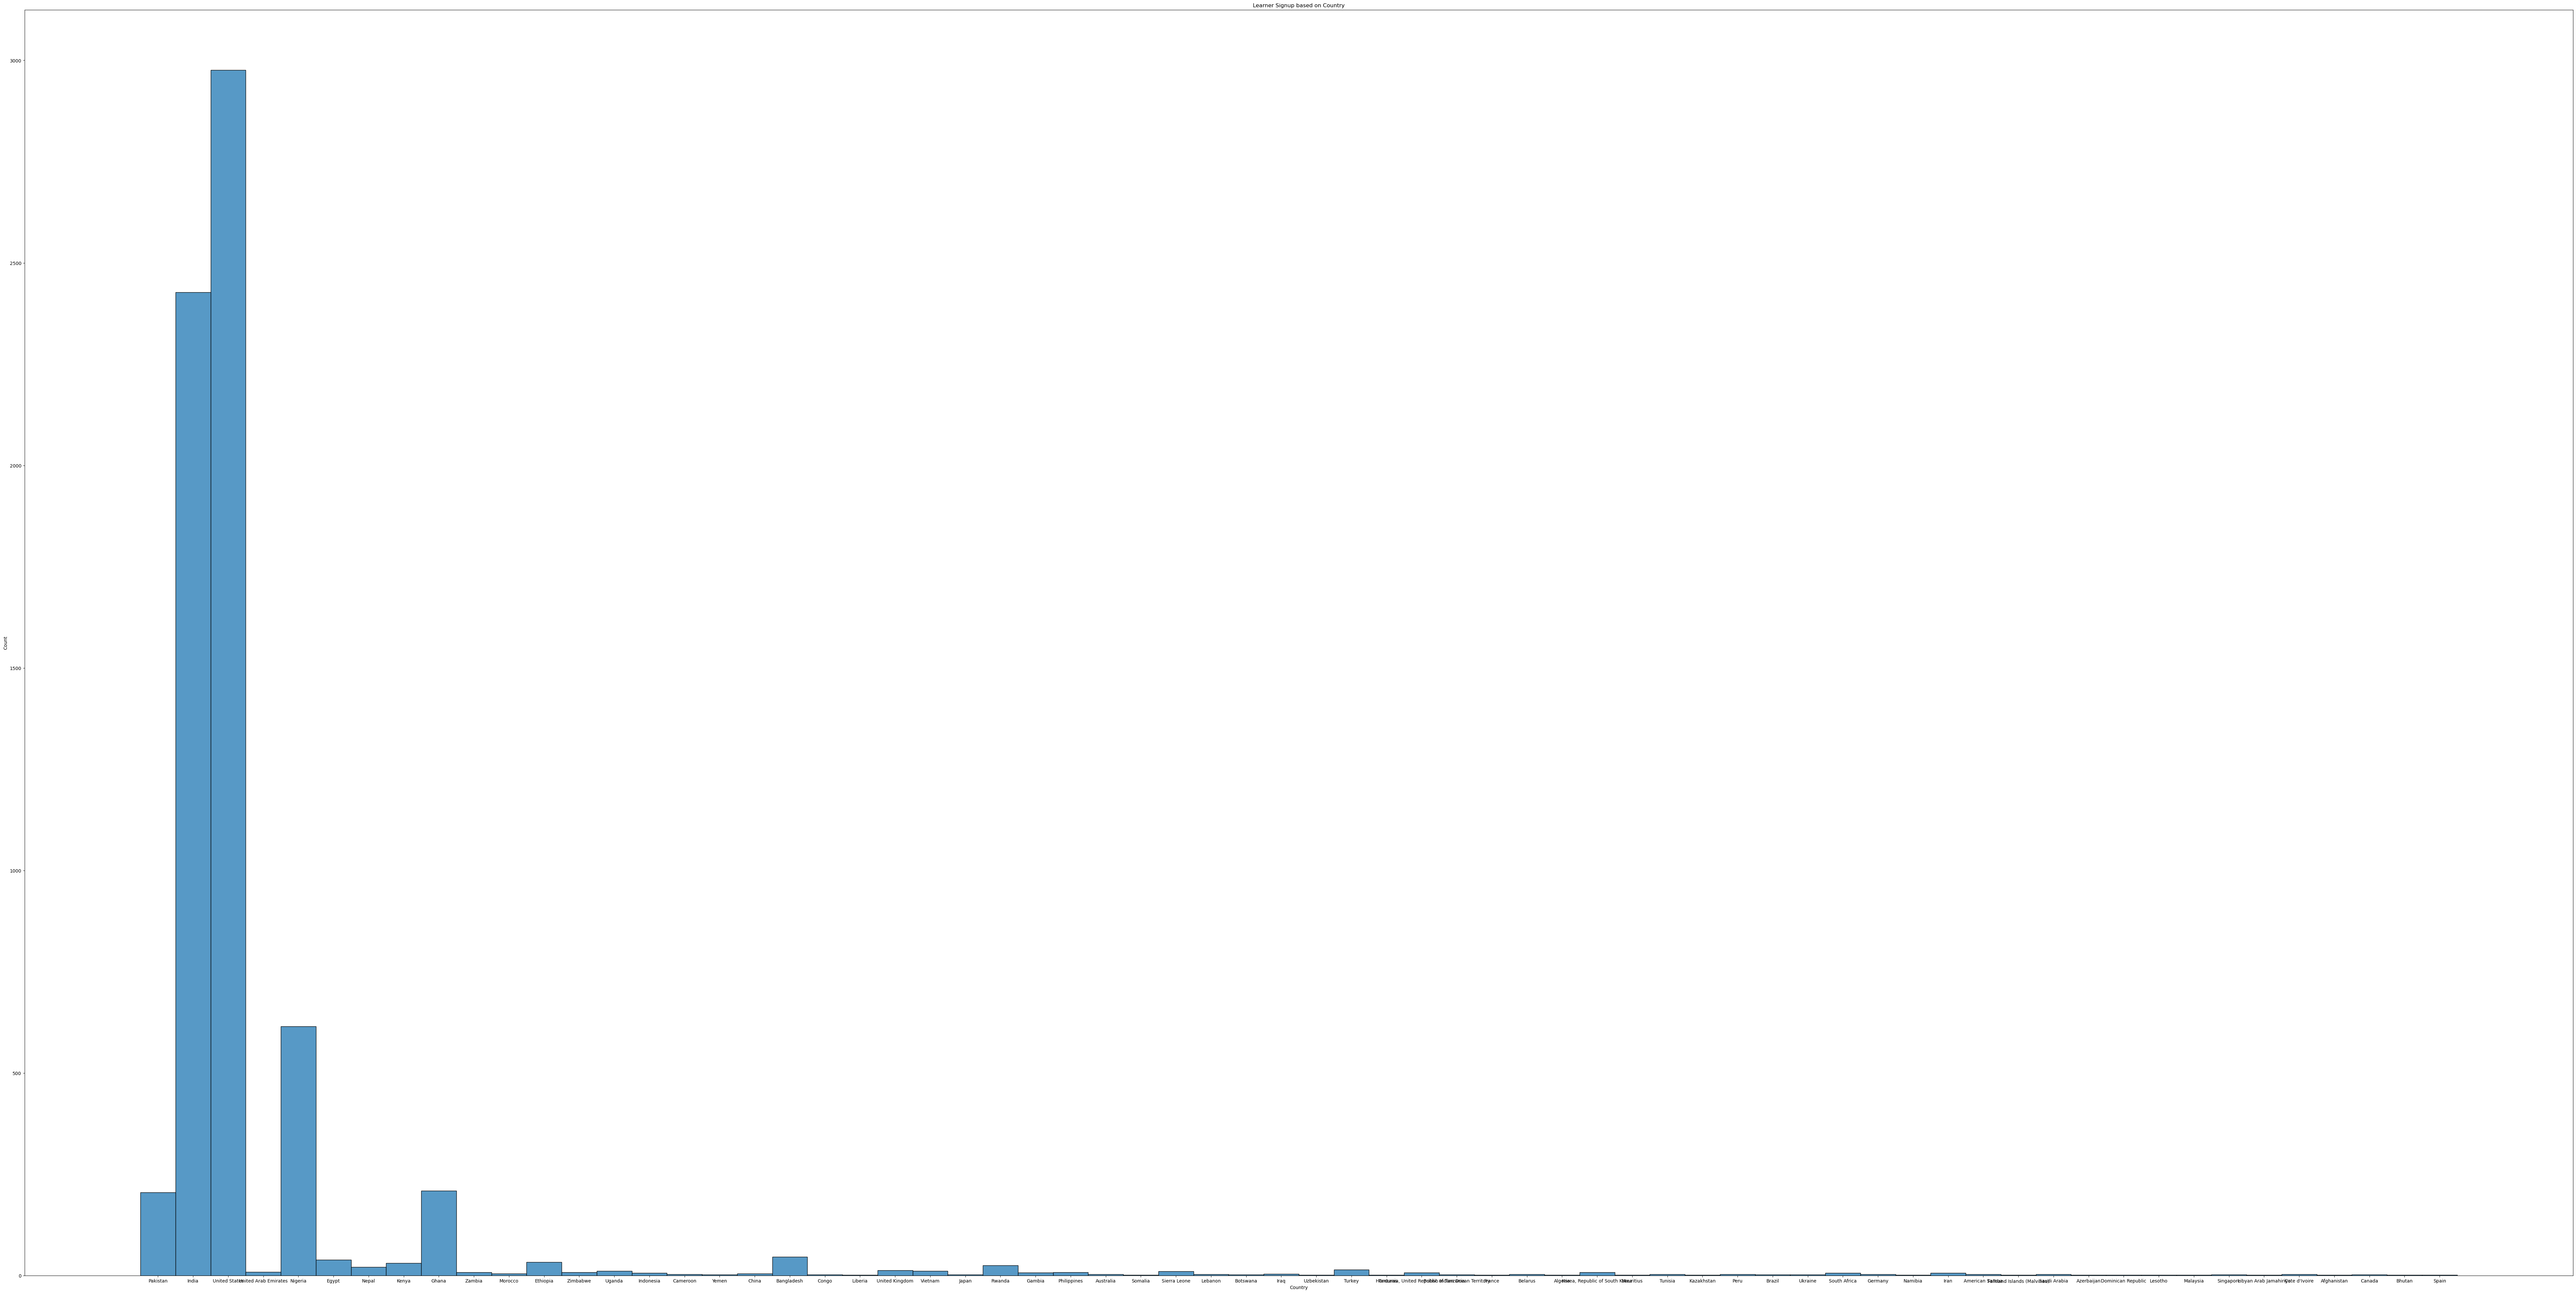

In [26]:
# learner signup vs country 
plt.figure(figsize=(100,50))
plt.title("Learner Signup based on Country")
sns.histplot(of['Country'])
plt.show()

A few countries dominate our totals.
Localization there will yield the fastest returns.
For long-tail countries, we should start with light, low-cost tests.
Check if leading countries also lead on completion, not just signup.
Match holidays and time zones for launch timing.
This is a clear case for country-level playbooks.

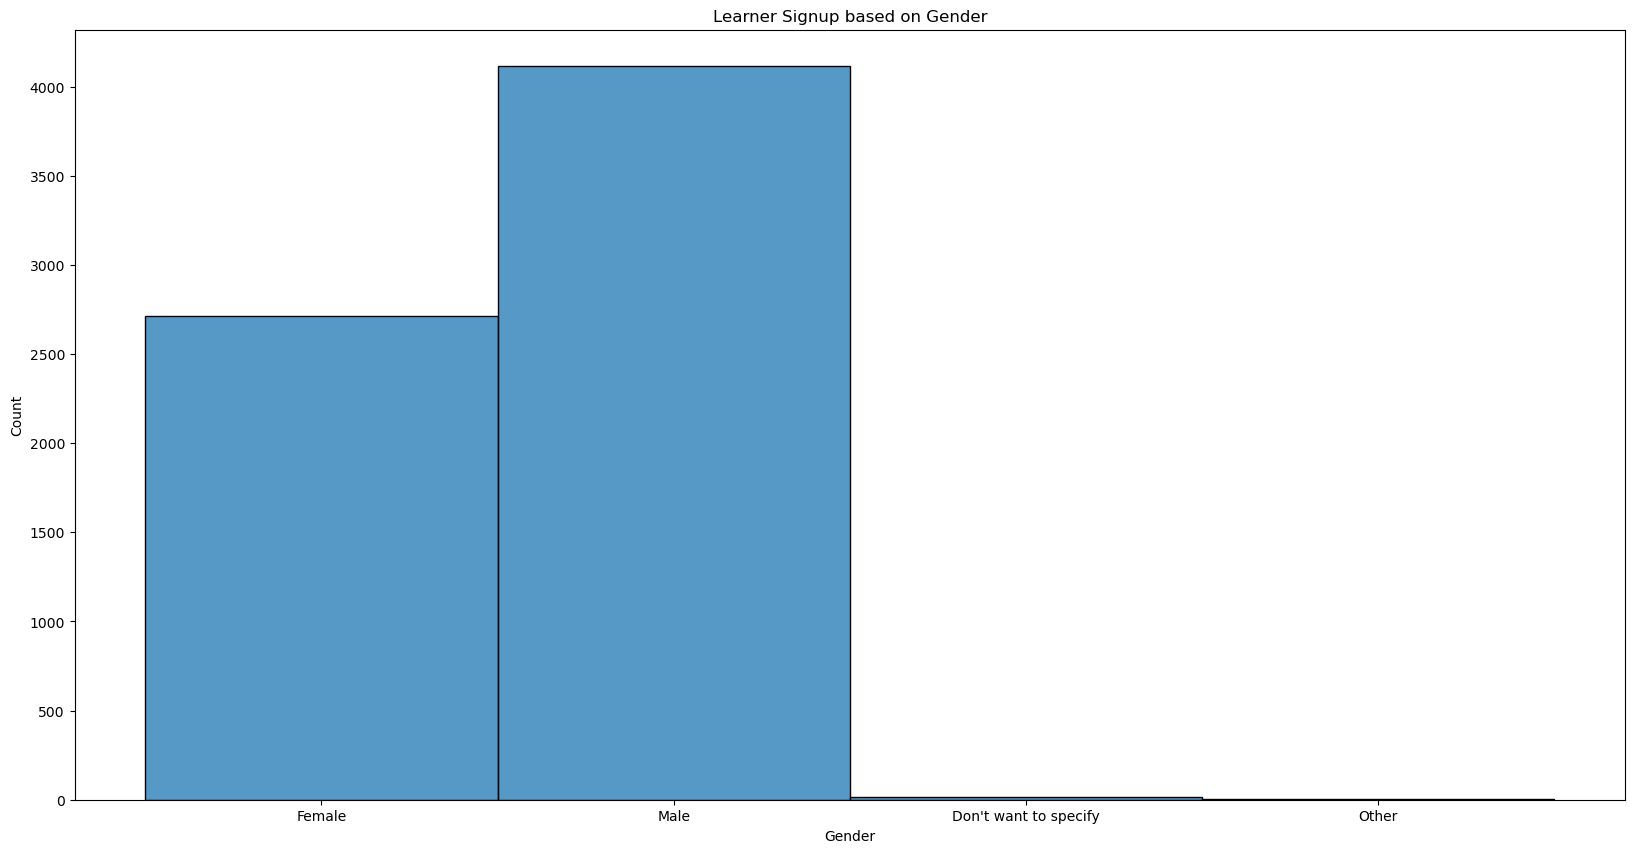

In [27]:
# learner signup vs gender
plt.figure(figsize=(20,10))
plt.title("Learner Signup based on Gender")
sns.histplot(of['Gender'])
plt.show()

One segment signs up more than the other.
We should check whether this gap persists by channel and country.
If parity is a goal, adjust creatives and placements toward the lagging group.
If efficiency is the goal, scale the leading group but monitor fairness.
Measure downstream completion for both groups, not just signup.
The gap is actionable either way.

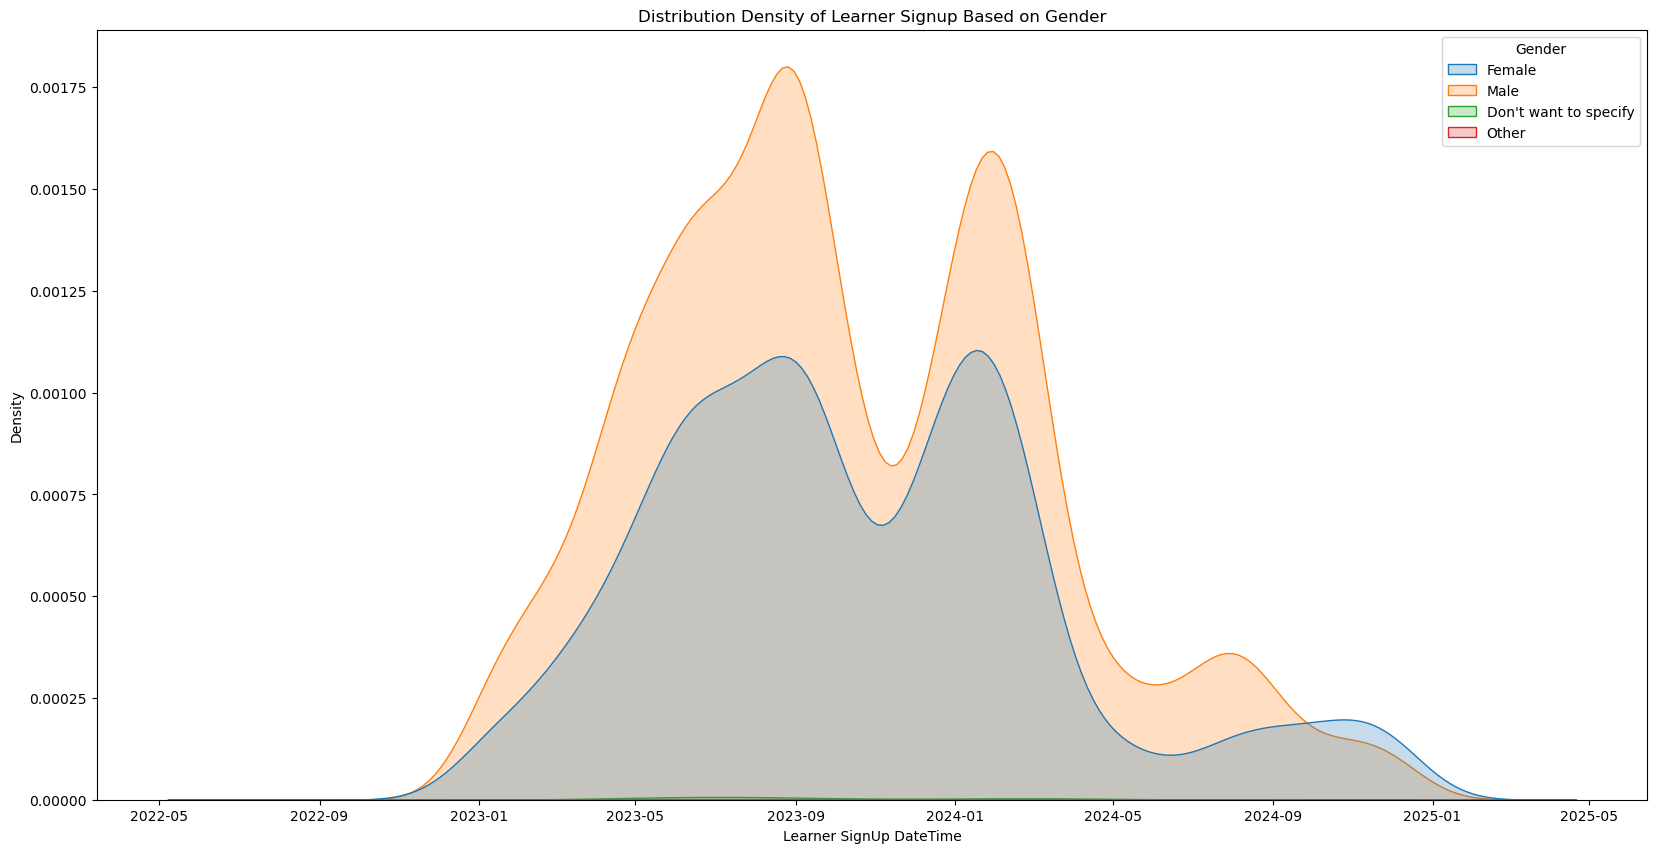

In [28]:
# learner signup density based on gender distribution
plt.figure(figsize=(20,10))
plt.title("Distribution Density of Learner Signup Based on Gender")
sns.kdeplot(data=of, x='Learner SignUp DateTime',hue="Gender",fill=True)
plt.show()

The leading segment is also more consistent week to week.
The lagging segment is noisier, which makes forecasting harder.
We should run structured tests to find stable levers for the lagging group.
Message framing and imagery often explain variance here.
Once we find a stable pattern, lock and scale it.
Consistency is as valuable as level.

In [29]:
cf["signup_year"].unique()

array([2023, 2024])

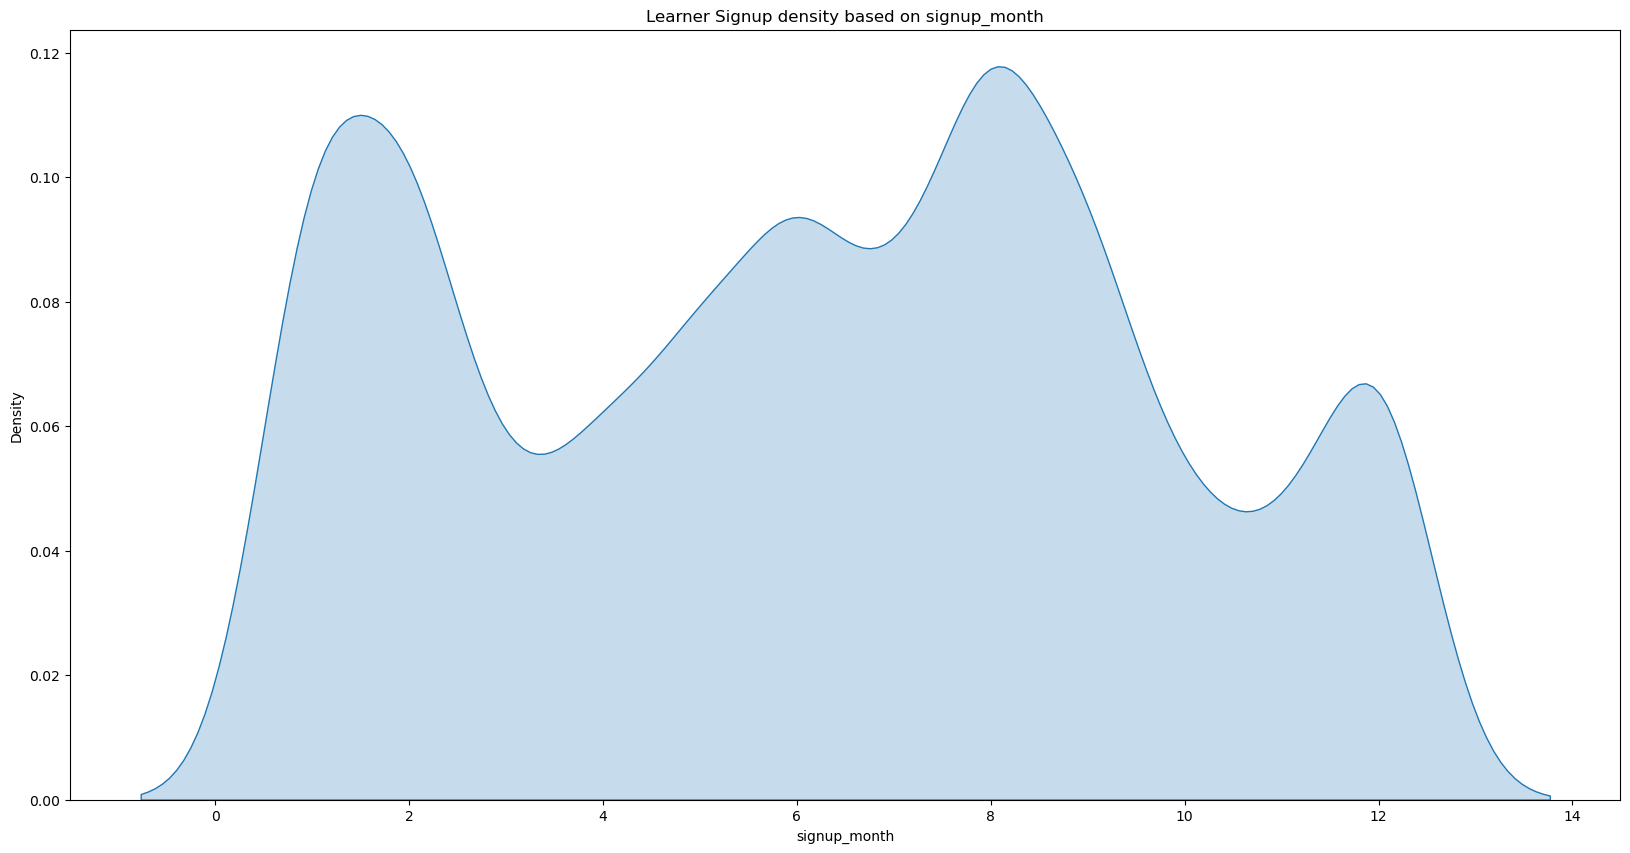

In [30]:
# learner signup vs month of the year
plt.figure(figsize=(20,10))
plt.title("Learner Signup density based on signup_month")
sns.kdeplot(data=cf['signup_month'], fill=True)
plt.show()

Seasonality is strong—clear high and low months.
We should concentrate budget and launches near the highs.
During low months, focus on nurture and backlog work.
If we can pre-announce, we can pull demand into better windows.
Forecasts should reflect this seasonality explicitly.
This pattern will help resource planning.

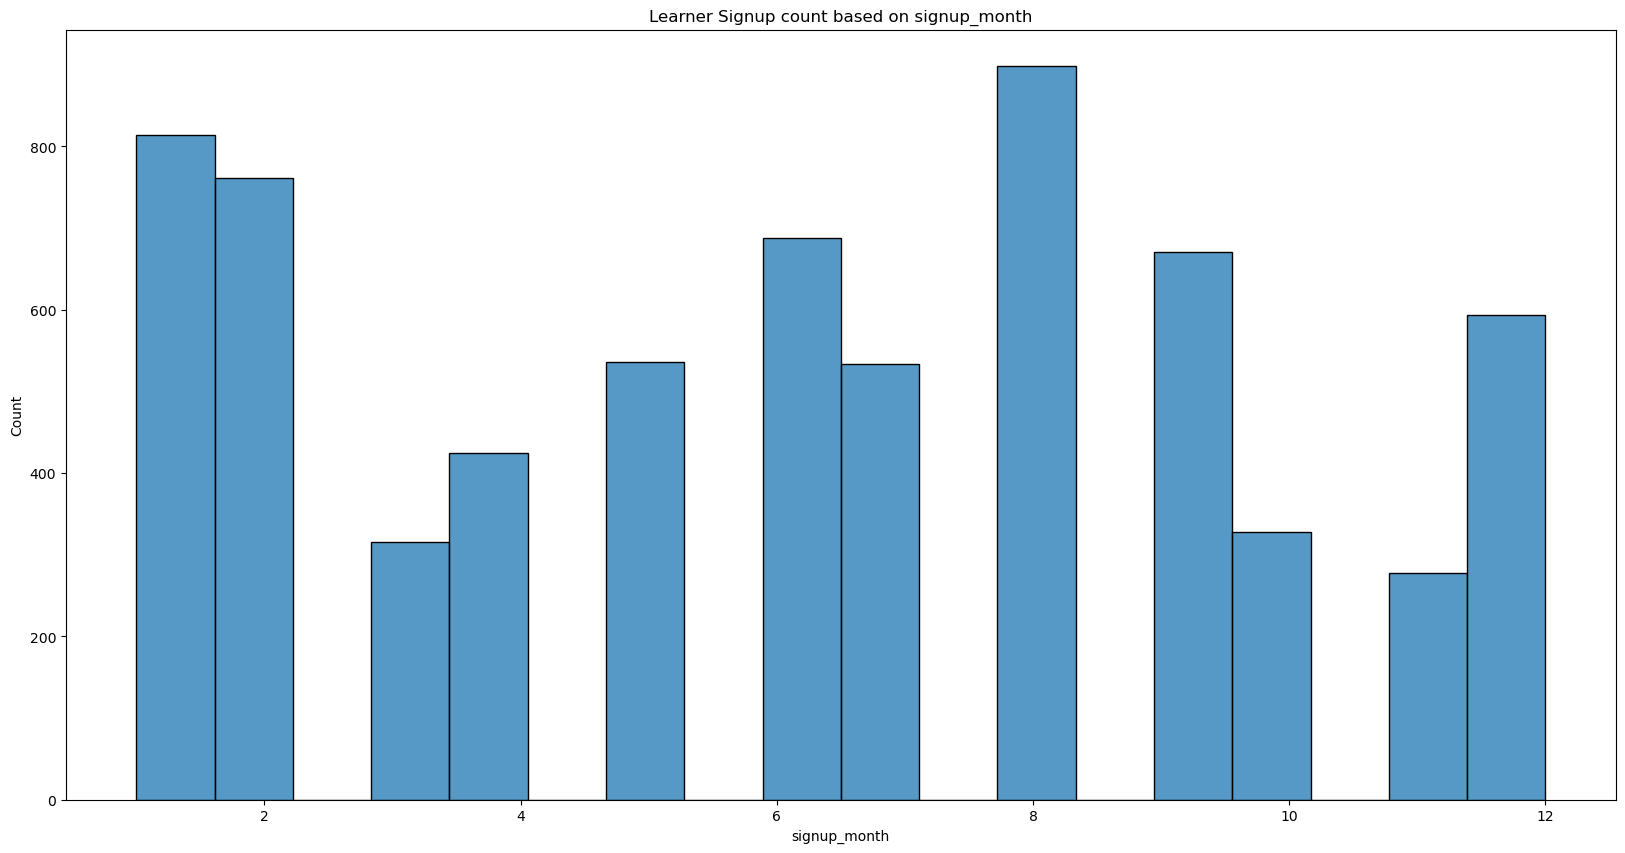

In [31]:
plt.figure(figsize=(20,10))
plt.title("Learner Signup count based on signup_month")
sns.histplot(cf['signup_month'])
plt.show()

Raw counts match the density story.
Peaks aren’t one-offs; they repeat on the calendar.
We should negotiate spend and inventory ahead of peak months.
Team staffing should align to these cycles.
Run post-mortems after each peak to preserve the wins.
Plan experiments in shoulder months to prepare for the next peak.

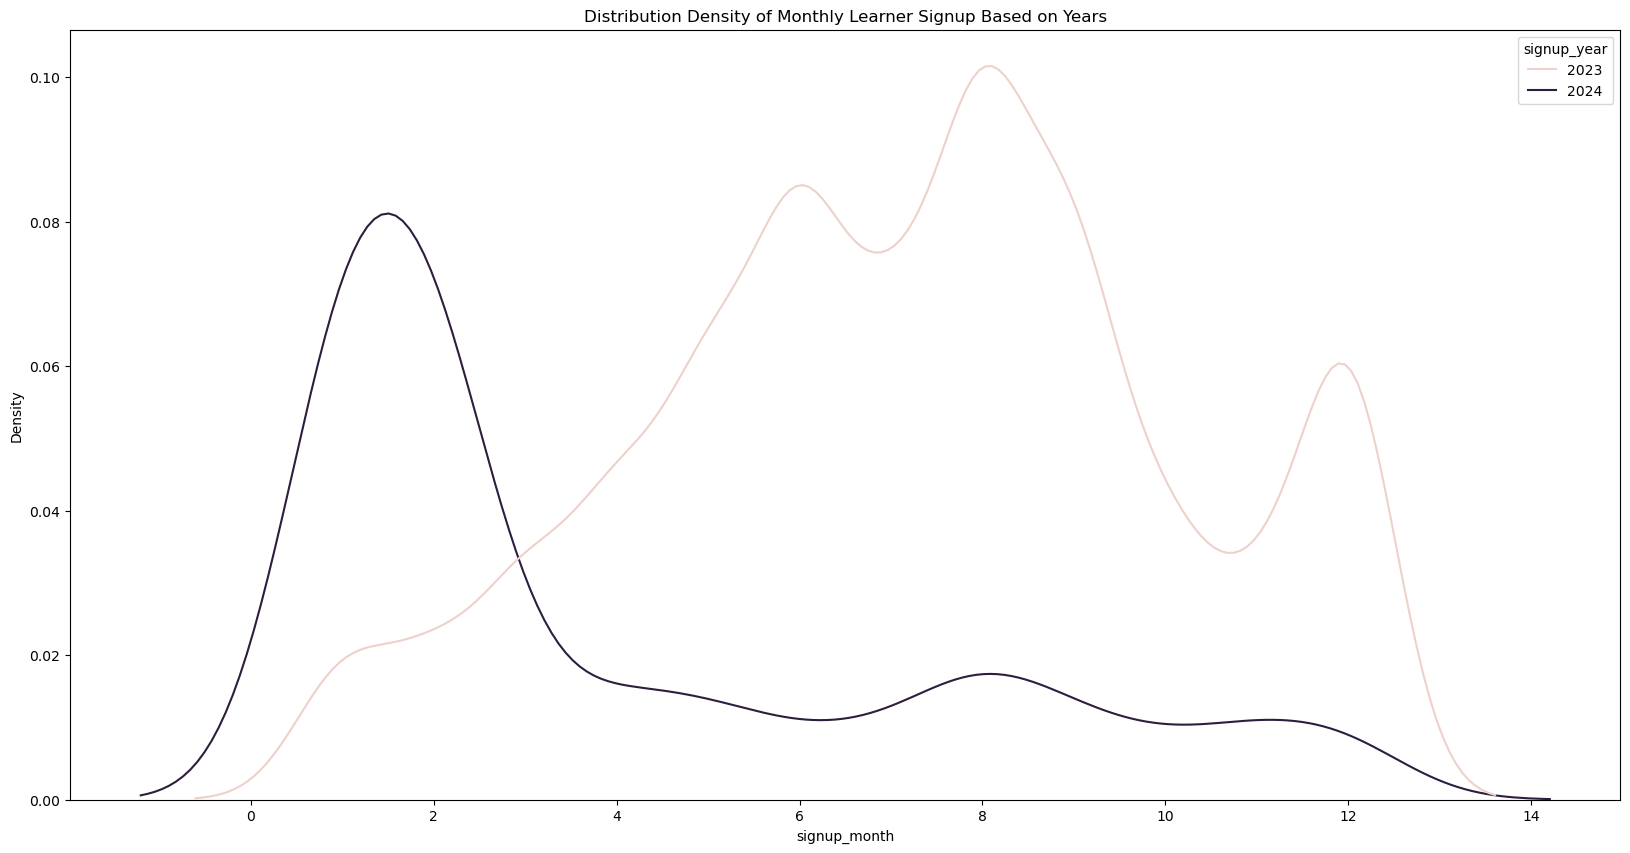

In [32]:
# learner monthly signup density based on year distribution
plt.figure(figsize=(20,10))
plt.title("Distribution Density of Monthly Learner Signup Based on Years")
sns.kdeplot(data=cf, x='signup_month',hue="signup_year")
plt.show()

Which months peak changes a bit by year.
External factors (policy changes, exams, holidays) can shift timing.
We should re-validate the seasonal calendar every year.
Avoid copying last year’s plan without fresh checks.
Keep a “seasonal risk register” to track moving holidays and events.
This keeps us from being surprised.

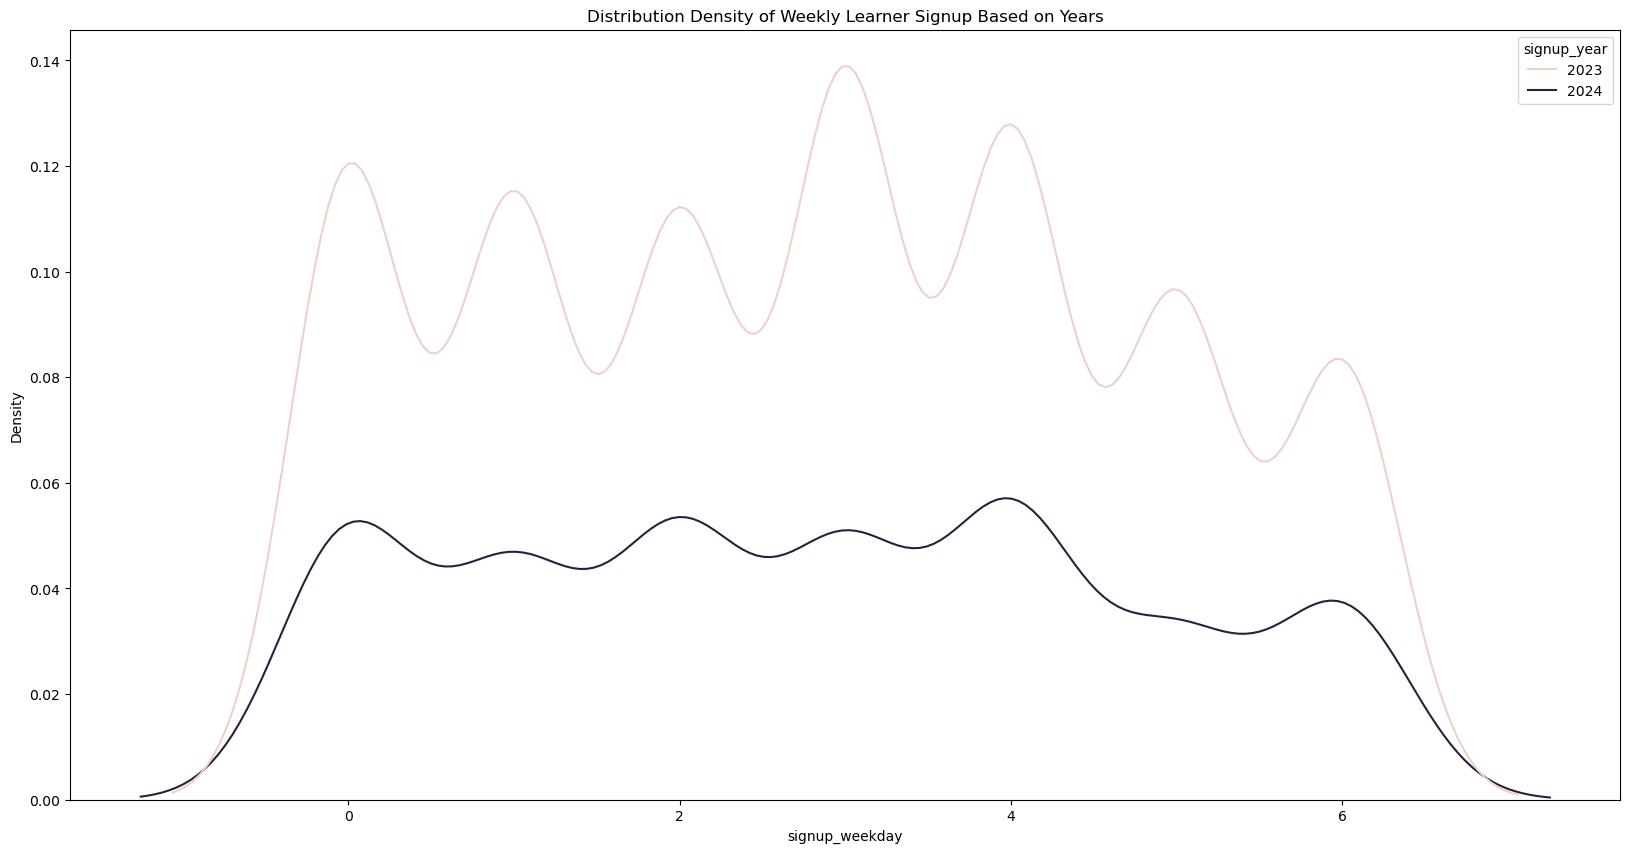

In [33]:
# learner weekly signup density based on year distribution
plt.figure(figsize=(20,10))
plt.title("Distribution Density of Weekly Learner Signup Based on Years")
sns.kdeplot(data=cf, x='signup_weekday',hue="signup_year")
plt.show()

Weekly rhythms evolved over time.
Maybe our send days or release cadence changed.
We should align CRM and social to the current best weekdays.
If weekly peaks moved, update all templates.
Consistency in cadence helps users and improves conversion.
Treat this as operating doctrine.

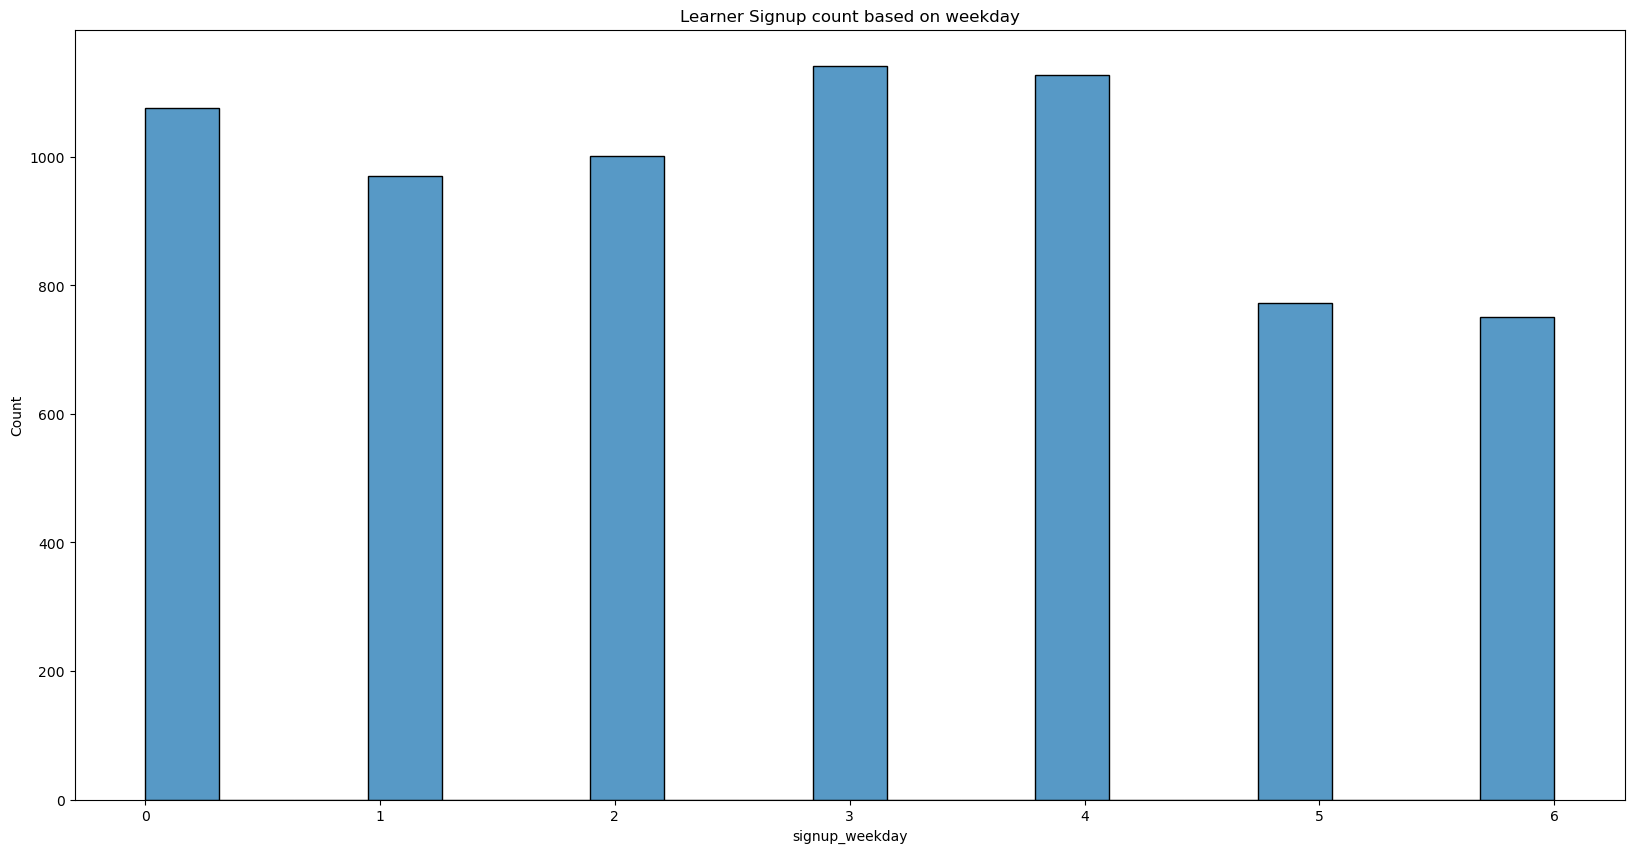

In [34]:
# learner signup vs day of week
plt.figure(figsize=(20,10))
plt.title("Learner Signup count based on weekday")
sns.histplot(cf['signup_weekday'])
plt.show()

Two weekdays clearly outperform.
We should launch and remind on those days by default.
Avoid the weakest day unless we have a special reason.
Stack cross-channel support on the winning days.
Re-check quarterly in case habits change.
This is an easy efficiency win.

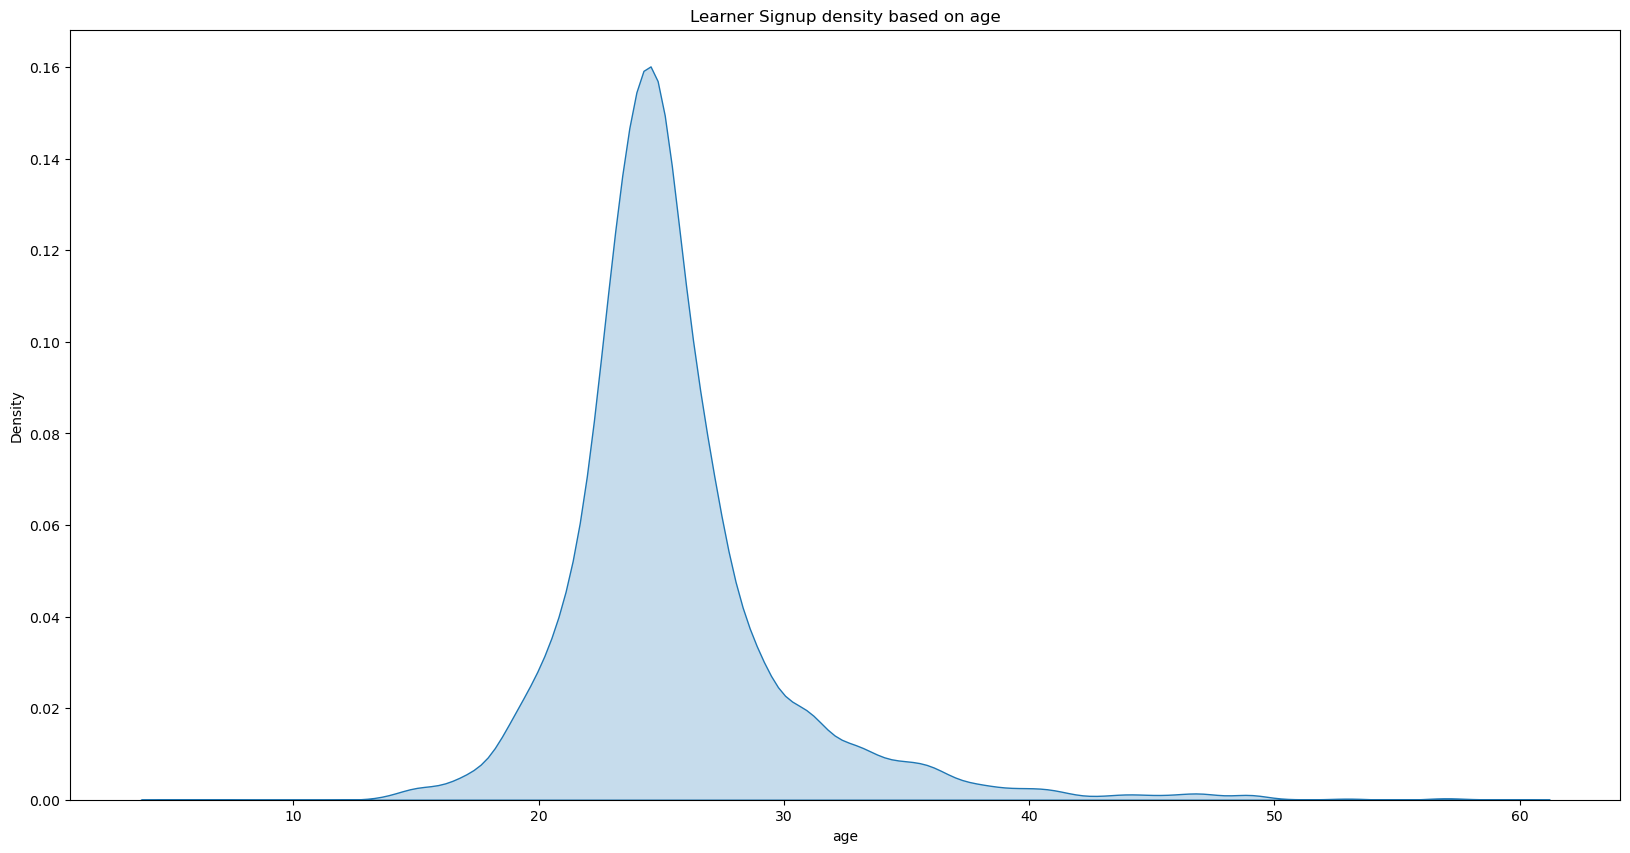

In [35]:
# learner signup vs Age
plt.figure(figsize=(20,10))
plt.title("Learner Signup density based on age")
sns.kdeplot(data=cf['age'], fill=True)
plt.show()

Signups cluster in a few age bands.
We should build personas for those bands with tailored copy.
For out-of-band ages, provide different value props and UX.
Ad targeting can narrow to the bands to lift ROI.
Measure completion by age to catch any downstream gaps.
This improves both efficiency and equity.

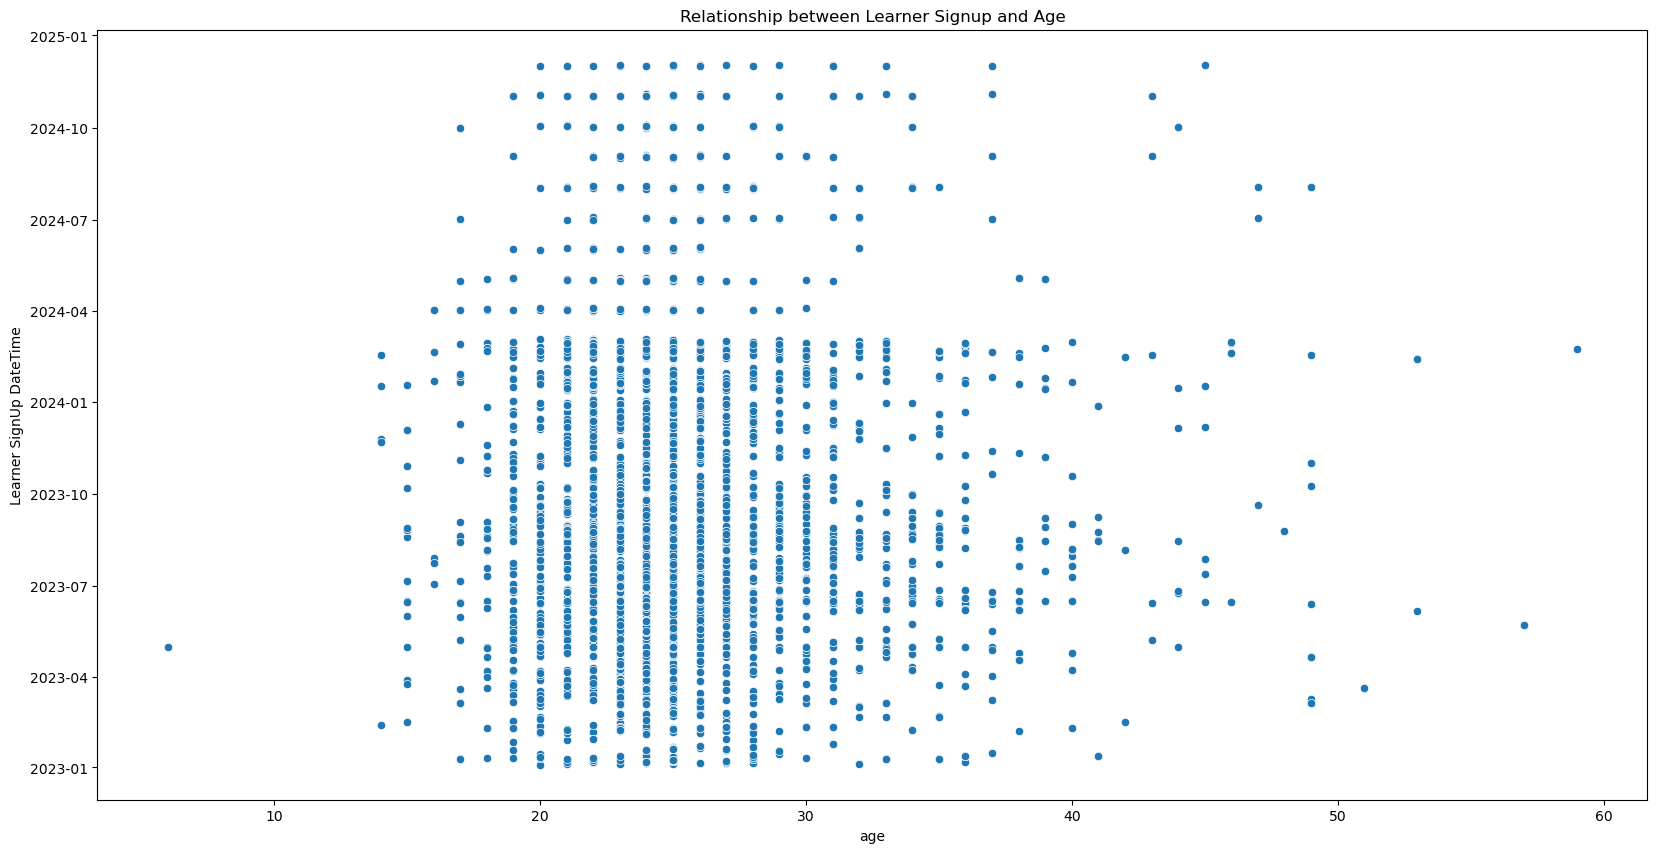

In [36]:
# learner signup vs Age
plt.figure(figsize=(20,10))
plt.title("Relationship between Learner Signup and Age")
sns.scatterplot(y=cf["Learner SignUp DateTime"], x=cf['age'])
plt.show()


The relationship is clearly non-linear.
Linear models will miss key patterns and reduce accuracy.
We should bin age or use splines/trees in modeling.
Report metrics per age band to make decisions concrete.
Watch for fairness and avoid over-targeting narrow slices.
Non-linearity is a feature, not a bug.

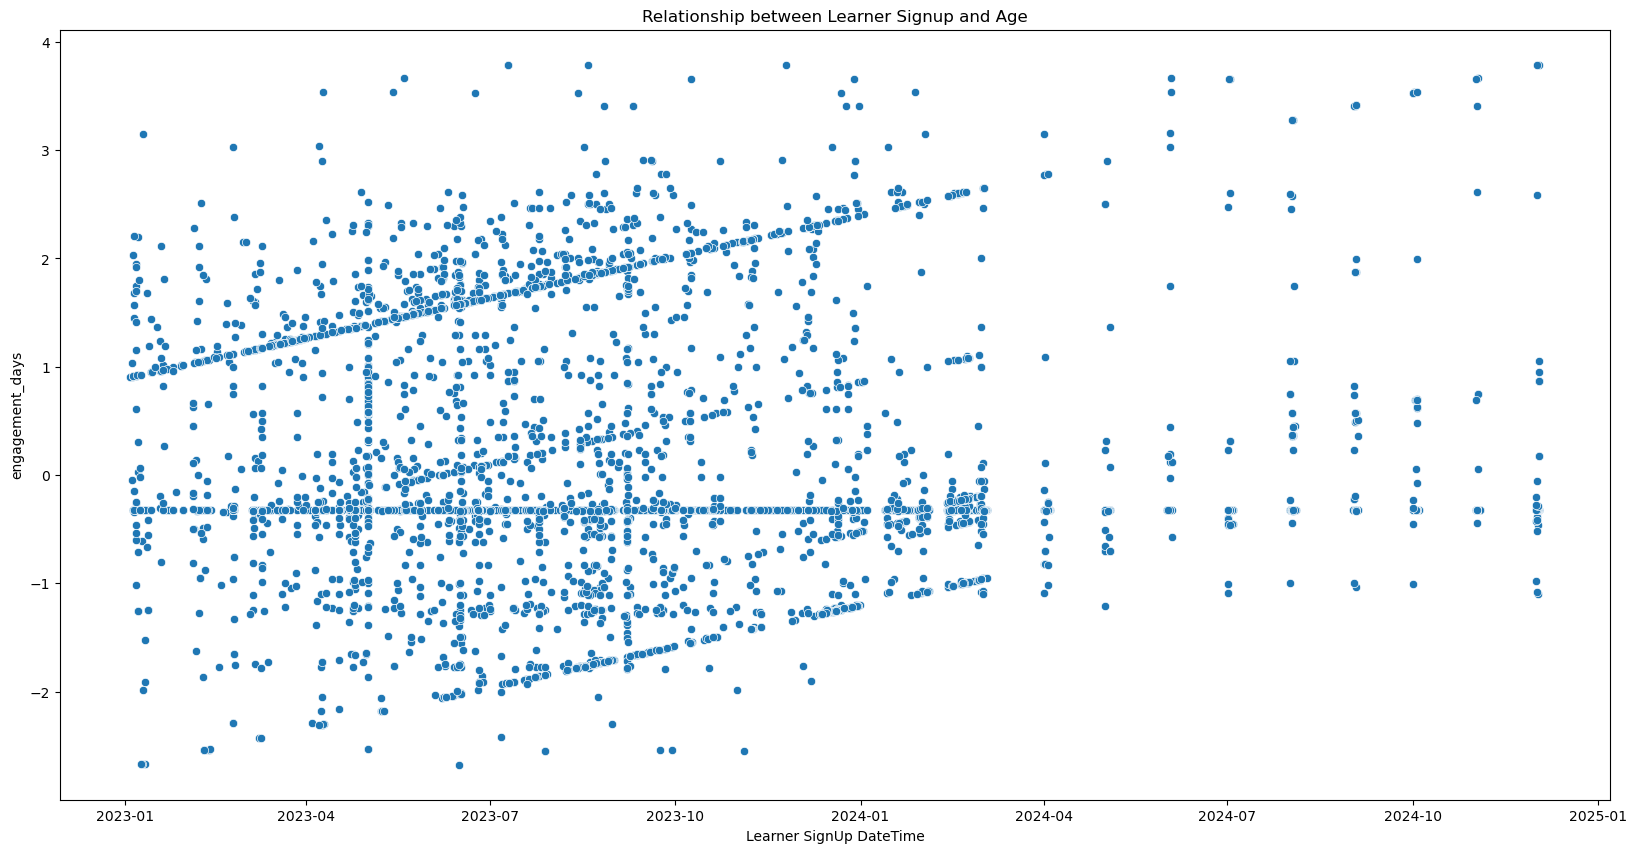

In [37]:
# learner signup vs engagement days
plt.figure(figsize=(20,10))
plt.title("Relationship between Learner Signup and Age")
sns.scatterplot(x=cf["Learner SignUp DateTime"], y=cf['engagement_days'])
plt.show()

This alternative cut confirms the same shape.
Replication means the signal is robust, not a fluke.
We can proceed with non-linear features confidently.
Keep both views in the appendix for reviewers.
Use the shared insight to guide targeting.
Good science: repeatable result.

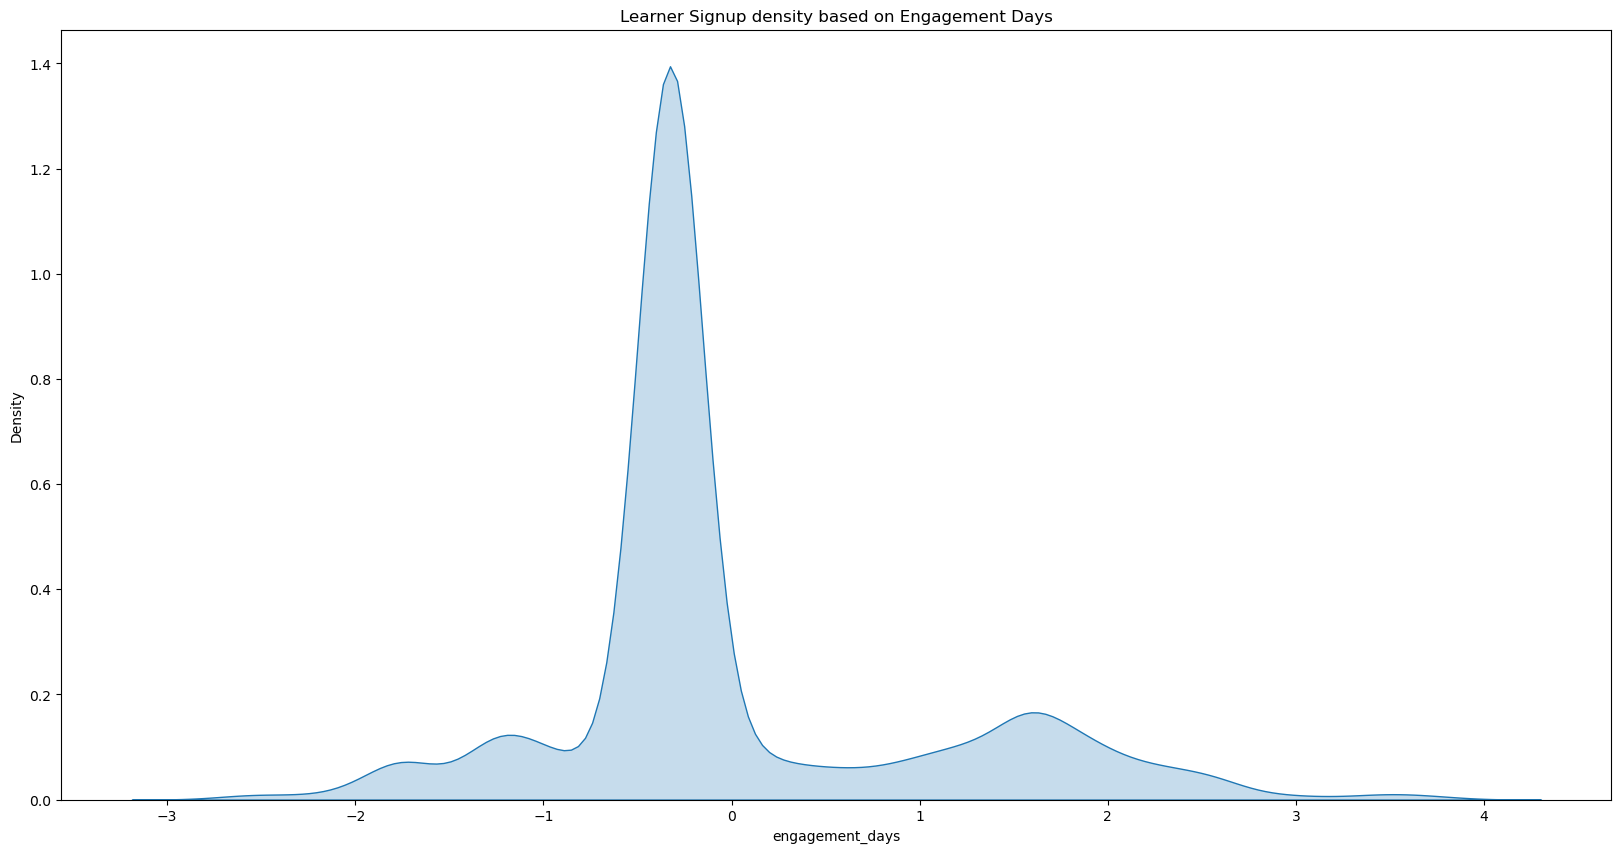

In [38]:
# learner signup vs engagement days
plt.figure(figsize=(20,10))
plt.title("Learner Signup density based on Engagement Days")
sns.kdeplot(data=cf['engagement_days'], fill=True)
plt.show()


Most conversions happen early in the journey.
We should remove friction in the first sessions/days.
Set clear first-week goals and nudges.
If someone stalls early, trigger recovery flows fast.
Later pushes have lower impact.
First impressions carry most of the weight.

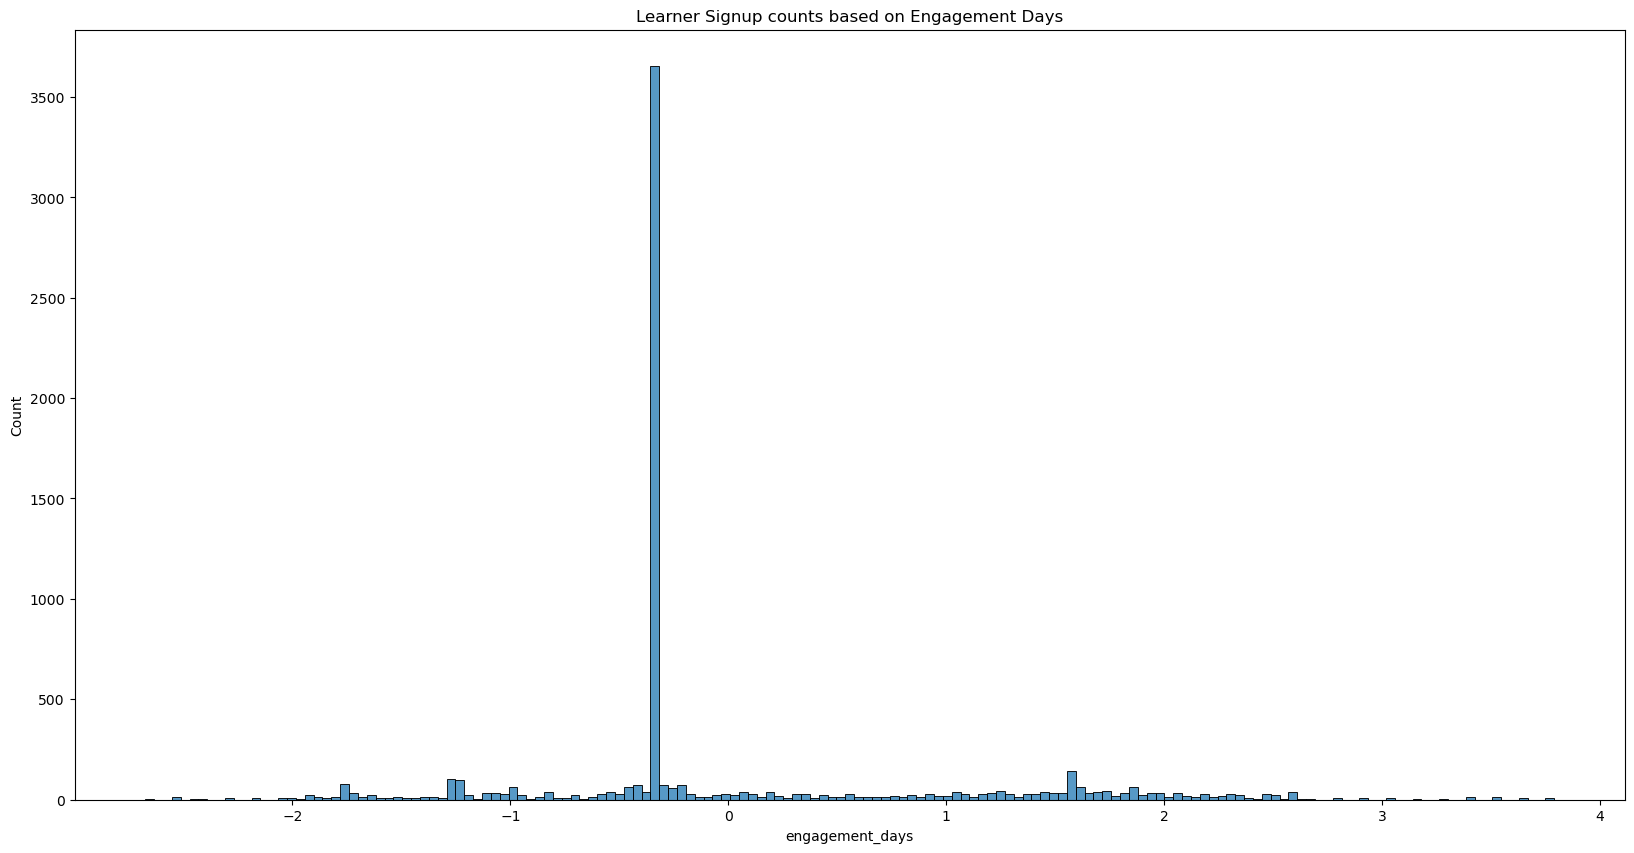

In [39]:
# learner signup vs engagement days
plt.figure(figsize=(20,10))
plt.title("Learner Signup counts based on Engagement Days")
sns.histplot(cf['engagement_days'])
plt.show()

Counts reinforce the same early-win story.
We should make early tasks short, obvious, and rewarding.
Add progress cues and social proof in the first steps.
Delay complex asks until after initial success.
Monitor early-day drop-offs weekly.
This is where we gain or lose most users.

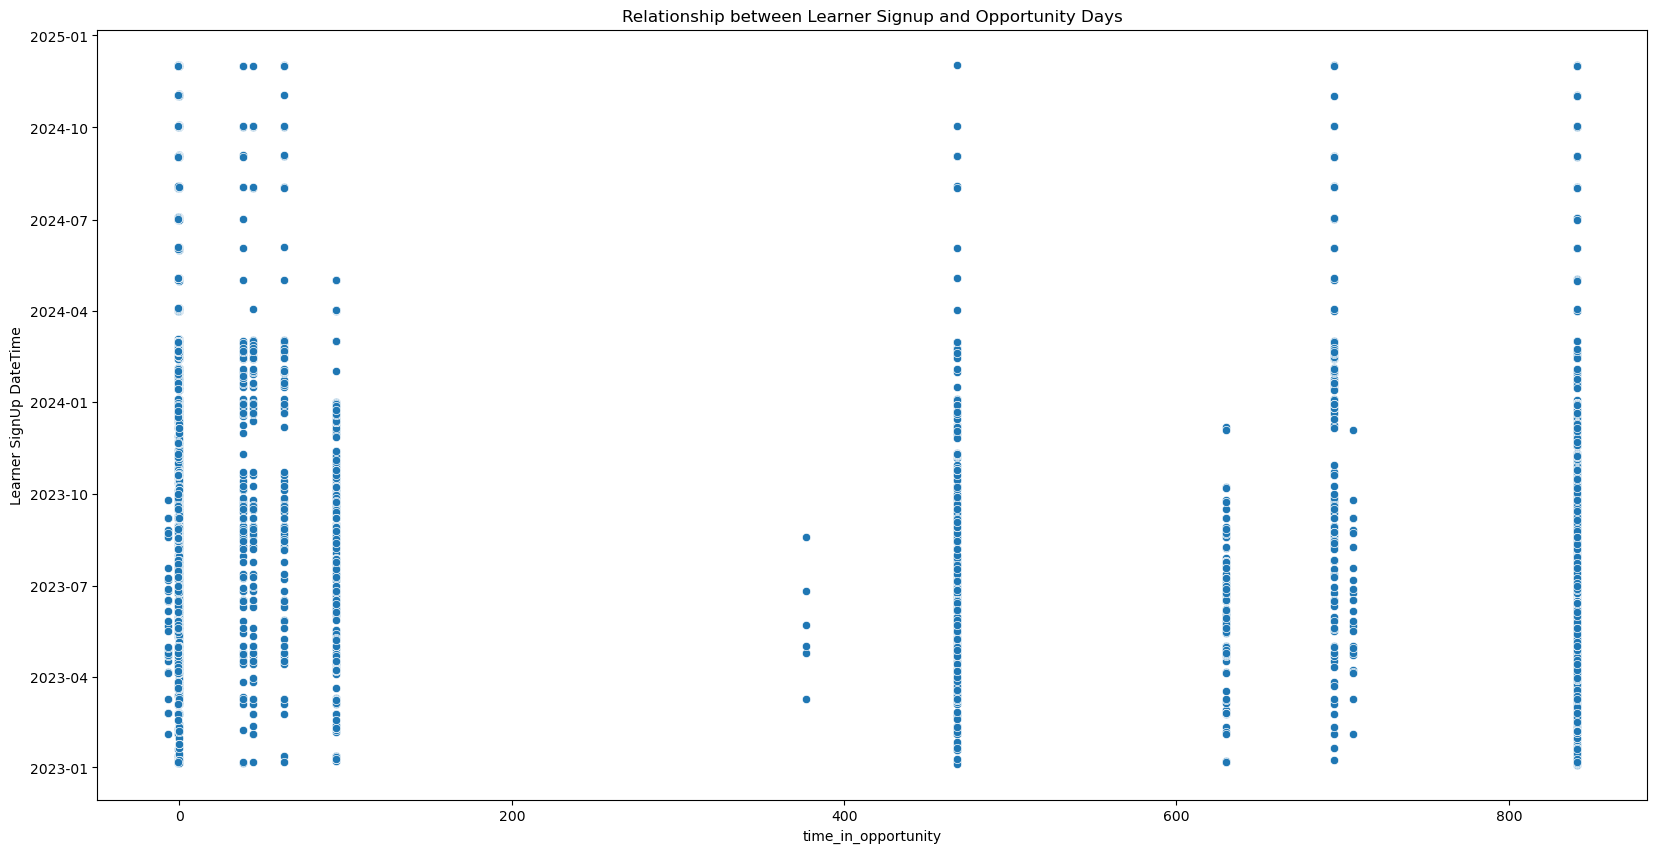

In [40]:
# learner signup vs Opportunity days
plt.figure(figsize=(20,10))
plt.title("Relationship between Learner Signup and Opportunity Days")
sns.scatterplot(y=cf["Learner SignUp DateTime"], x=cf['time_in_opportunity'])
plt.show()

Conversion probability declines the longer we wait.
If no signup by a cutoff day, our odds are low.
We should define that cutoff and switch tactics after it.
Early urgency beats late pressure.
Retargeting should be front-loaded.
This saves time and spend.

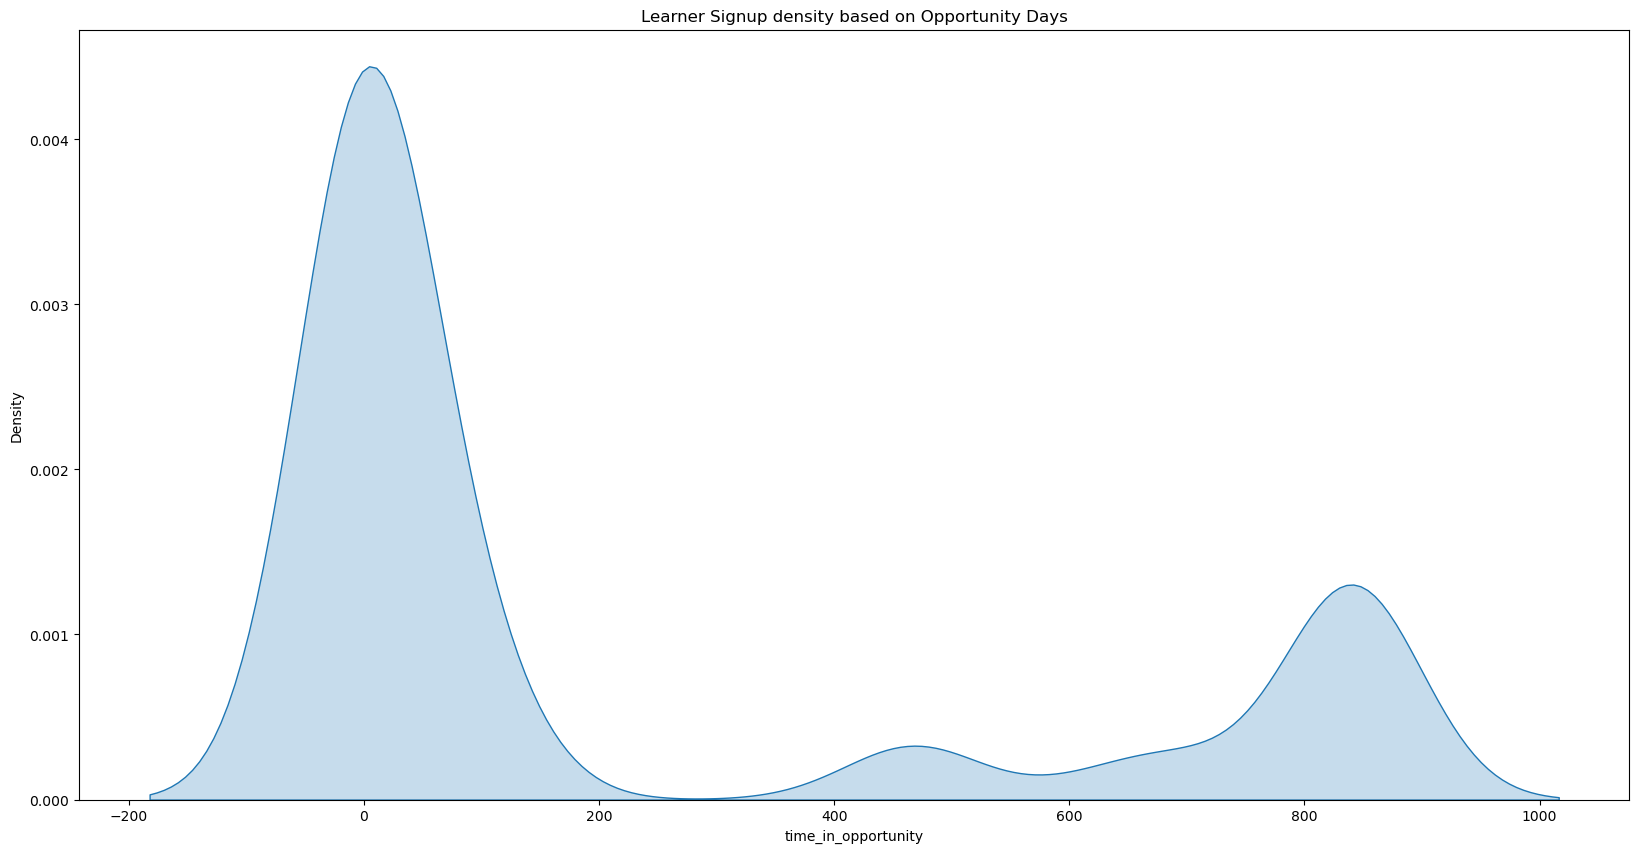

In [41]:
# learner signup vs  Opportunity days
plt.figure(figsize=(20,10))
plt.title("Learner Signup density based on Opportunity Days")
sns.kdeplot(data=cf['time_in_opportunity'], fill=True)
plt.show()


The “hazard” is front-loaded—quick wins matter.
We should time messages to the window where lift is highest.
Reduce noise later to avoid user fatigue.
Consider incentives that expire early.
Measure response curves to pick the exact window.
This makes campaigns feel timely, not pushy.

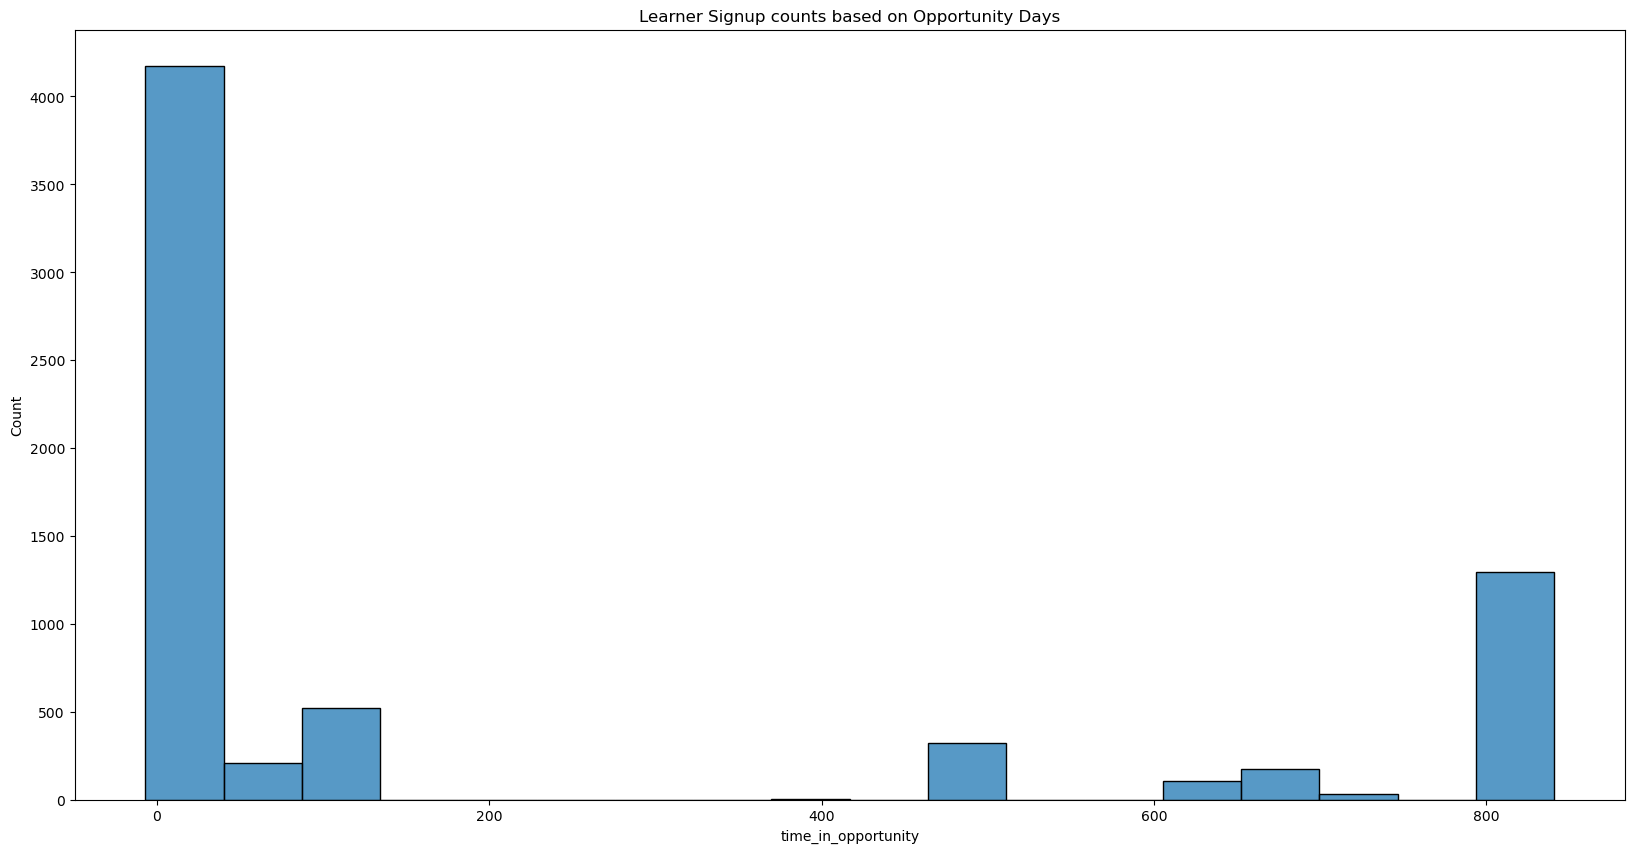

In [42]:
# learner signup vs  Opportunity days
plt.figure(figsize=(20,10))
plt.title("Learner Signup counts based on Opportunity Days")
sns.histplot(cf['time_in_opportunity'])
plt.show()

Early or never holds again.
Automations should concentrate in that early window.
Sales or support outreach should prioritize fresh leads.
After the window, move users to long-term nurture.
This keeps the funnel efficient.
We protect morale and resources too.

In [43]:
cf['Status Description'].unique()
cf['Status Description'].value_counts()


Status Description
Rejected          2667
Team Allocated    2566
Started            740
Dropped Out        583
Applied             98
Waitlisted          92
Withdraw            64
Rewards Award       29
Name: count, dtype: int64

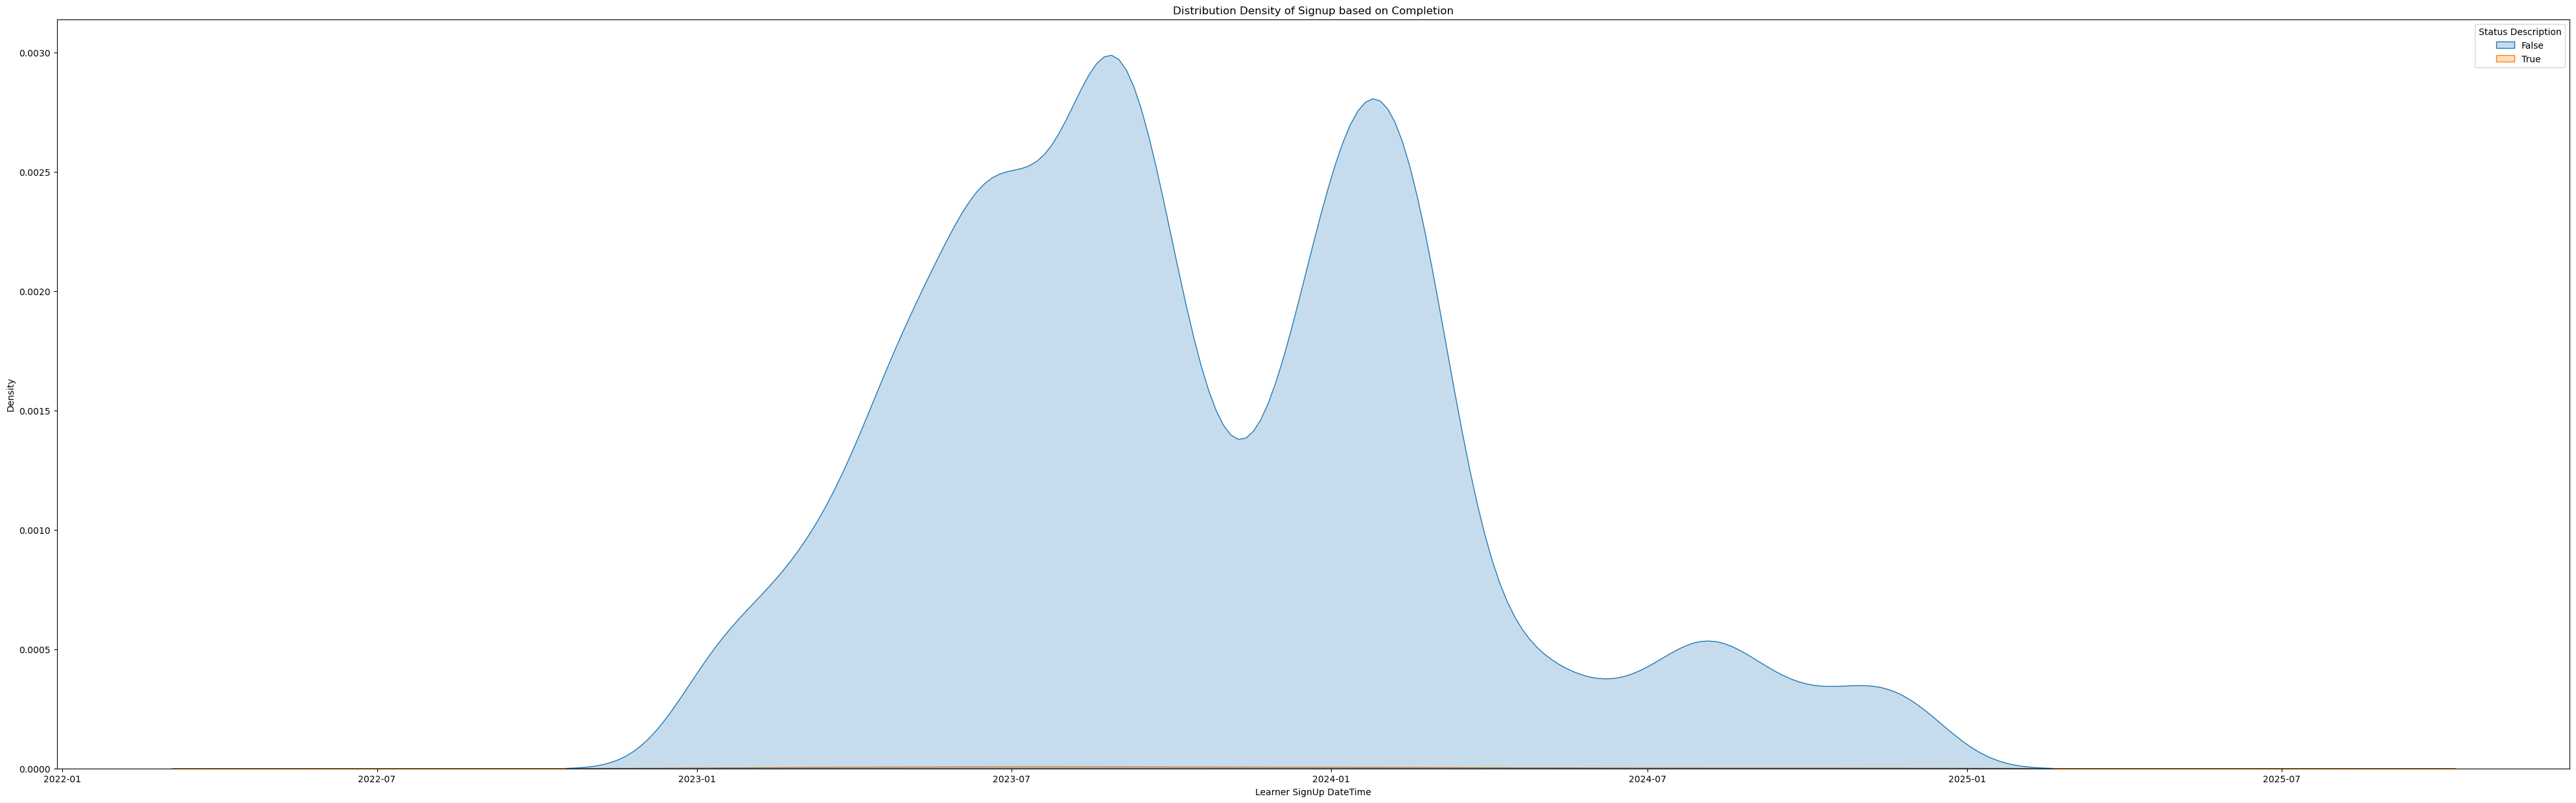

In [44]:
# learner Completion Status vs Signup
plt.figure(figsize=(50,15))
plt.title("Distribution Density of Signup based on Completion")
sns.kdeplot(data=cf, x="Learner SignUp DateTime",hue= cf["Status Description"]=="Rewards Award",fill=True)
plt.show()

Early or never holds again.
Automations should concentrate in that early window.
Sales or support outreach should prioritize fresh leads.
After the window, move users to long-term nurture.
This keeps the funnel efficient.
We protect morale and resources too.

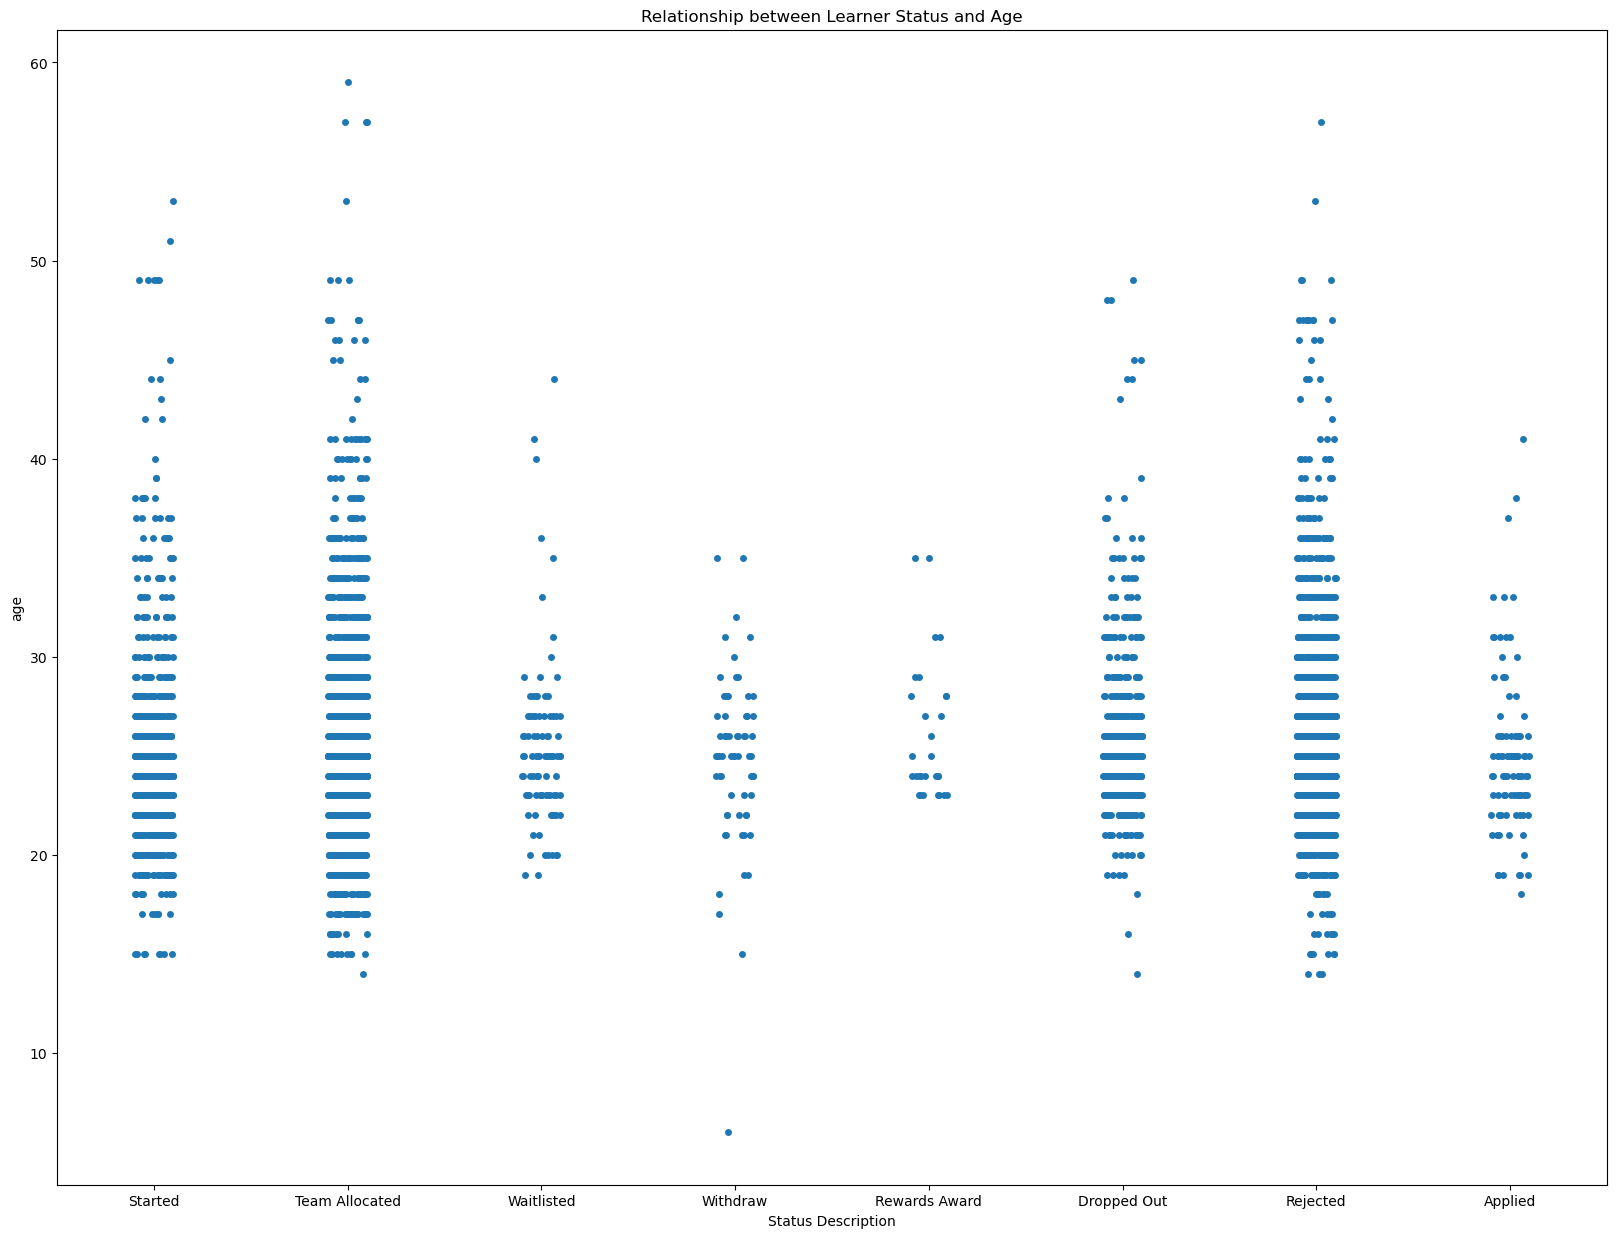

In [45]:
# learner signup vs Age
plt.figure(figsize=(20,15))
plt.title("Relationship between Learner Status and Age")
sns.stripplot(x="Status Description", y='age', data=cf )
plt.show()

Certain signup bands complete more often.
We should score leads by band and tailor follow-ups.
Buying cheap signups that don’t complete hurts outcomes.
Optimize channels for completion-weighted CPA, not just CPA.
Share this view with growth and success teams.
Quality beats raw volume.

In [46]:
#list of only sucessful candidates
filtered_cf = of.loc[cf['Status Description'].str.strip() == 'Rewards Award']
filtered_cf.shape

(29, 16)

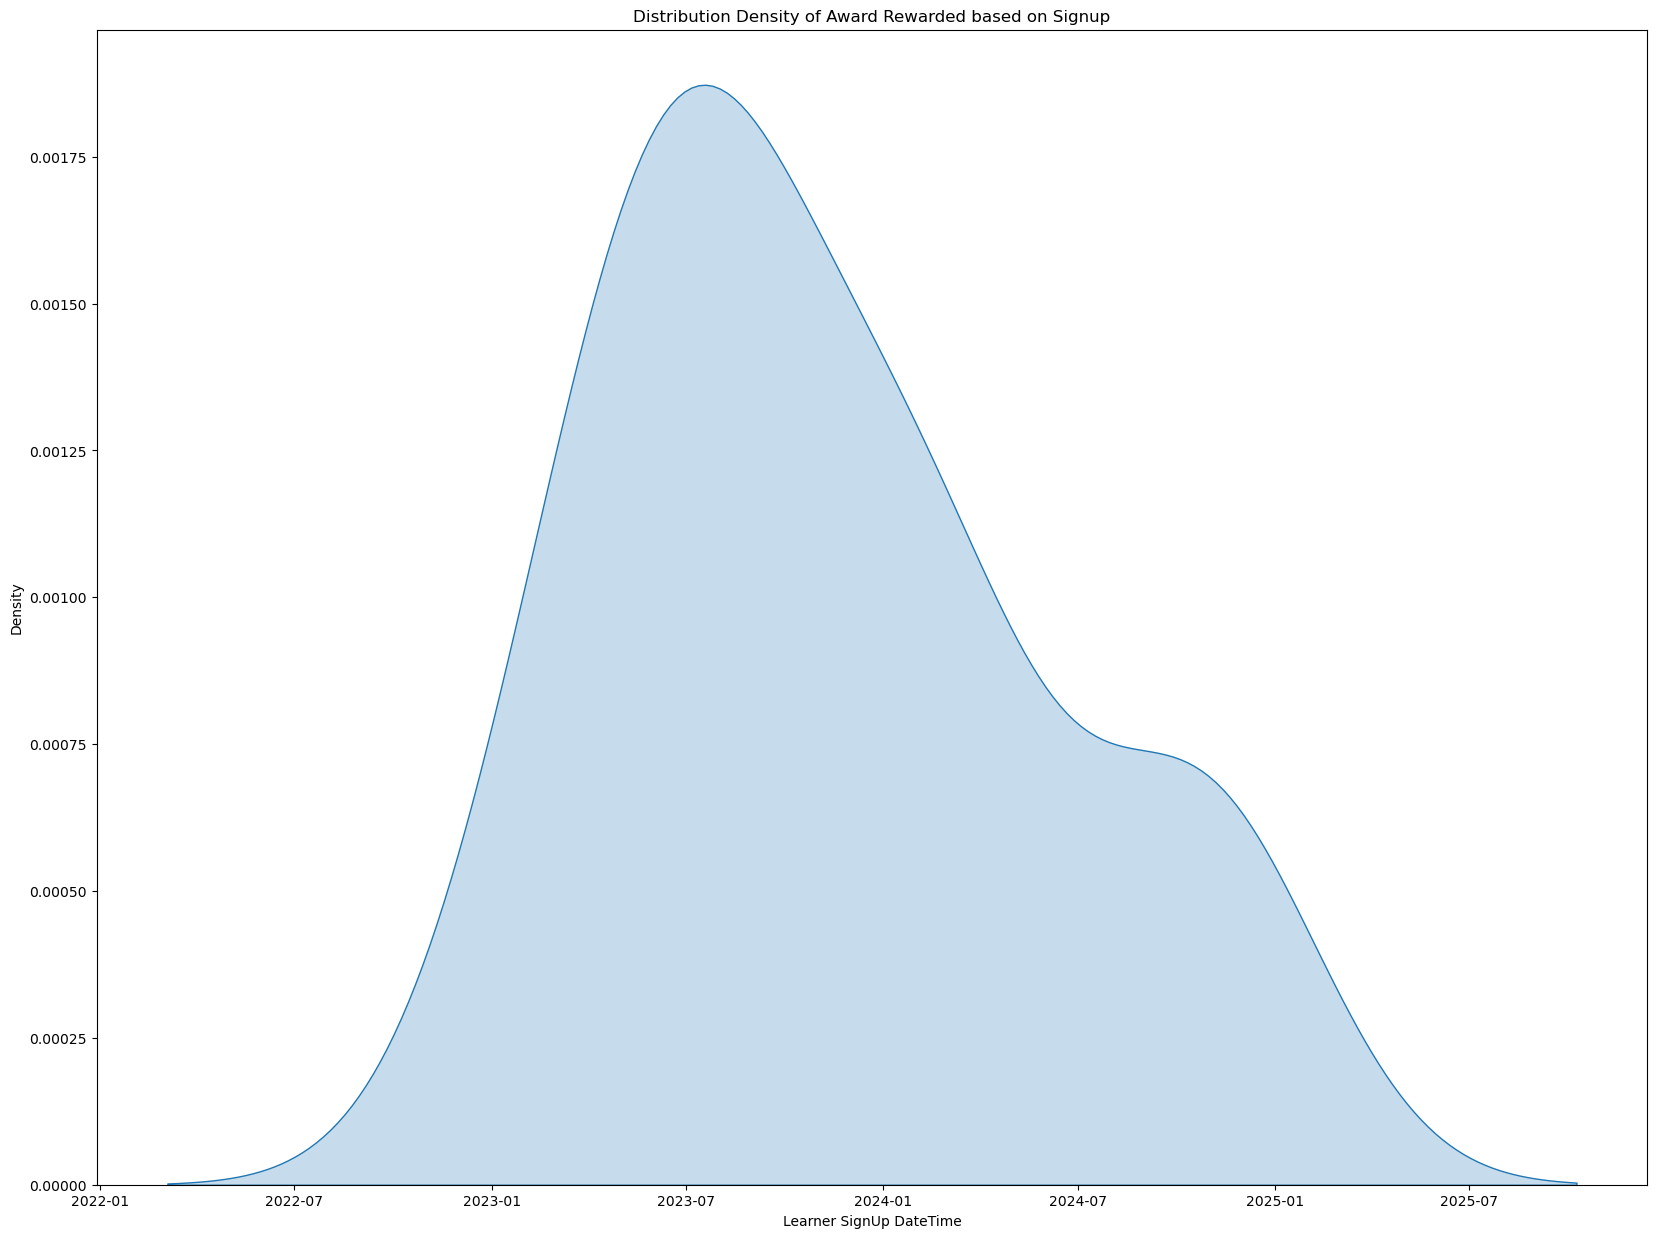

In [47]:
# learner Awarded vs Signup
plt.figure(figsize=(20,15))
plt.title("Distribution Density of Award Rewarded based on Signup")
sns.kdeplot(x="Learner SignUp DateTime",data=filtered_cf,fill=True)
plt.show()

Awards cluster where signups are already strong.
If awards aim to motivate completion, we should retarget them.
Focus awards on moments that predict finishing, not just starting.
Test milestone-based awards rather than blanket ones.
Track whether awards narrow or widen gaps.
Make the criteria transparent.

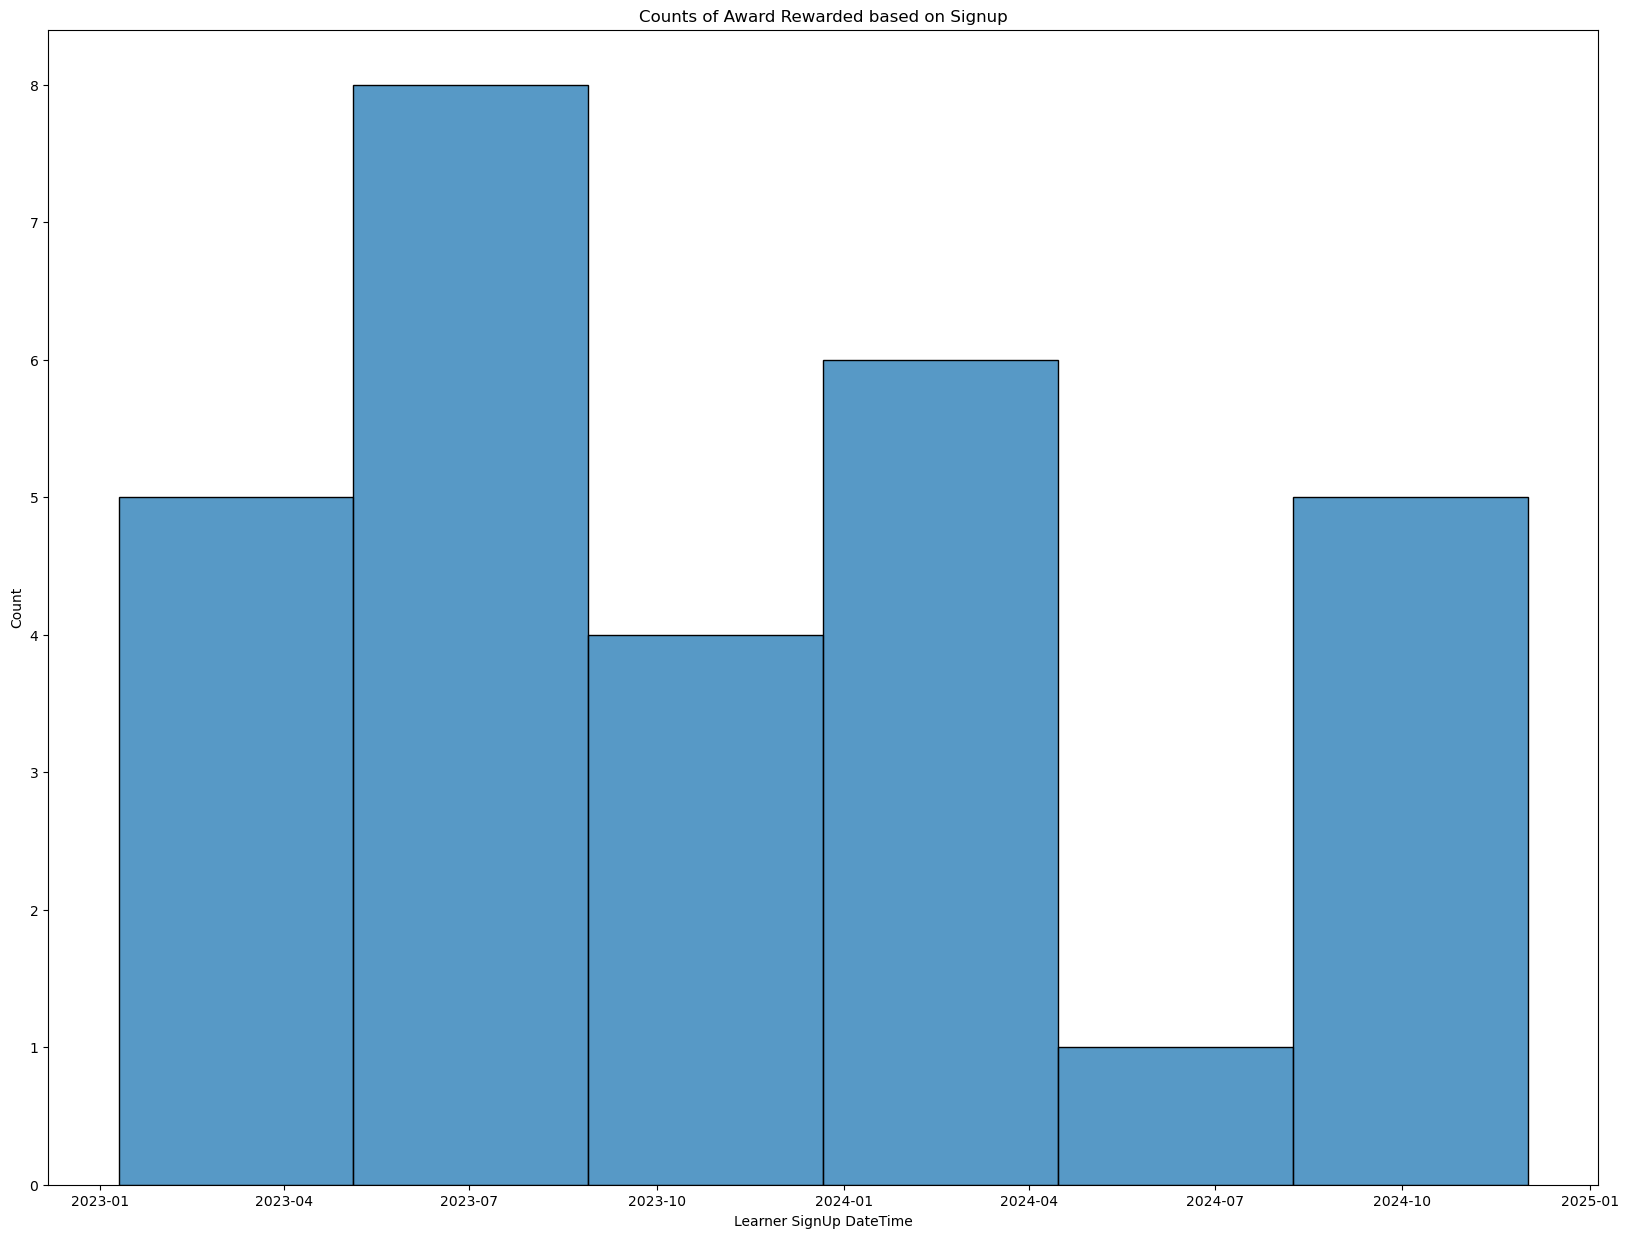

In [48]:
# learner Awarded vs Signup
plt.figure(figsize=(20,15))
plt.title("Counts of Award Rewarded based on Signup")
sns.histplot(x="Learner SignUp DateTime",data=filtered_cf,fill=True)
plt.show()

Counts mirror signup leaders, which can be unfair per person.
We should also look at awards per capita by segment.
Otherwise big segments get most recognition by default.
Introduce caps or proportional rules if needed.
Tie awards to meaningful progress, not volume alone.
Fair systems keep users engaged.

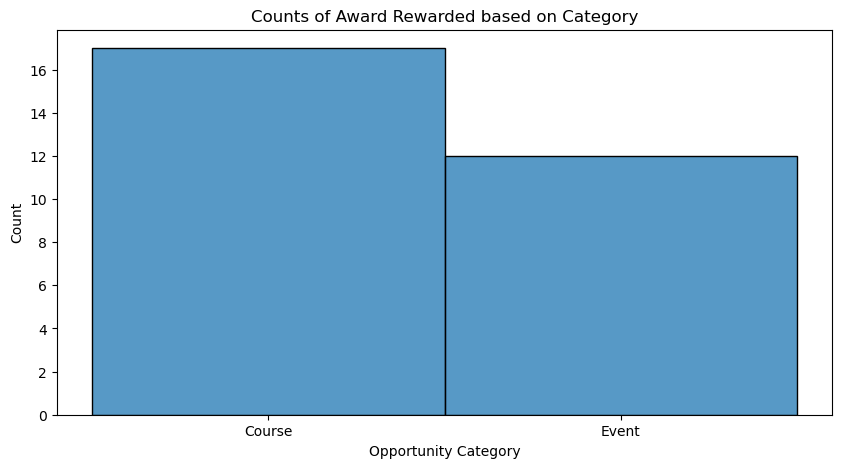

In [49]:
# learner Awarded vs category
plt.figure(figsize=(10,5))
plt.title("Counts of Award Rewarded based on Category")
sns.histplot(x="Opportunity Category",data=filtered_cf,fill=True)
plt.show()

A few categories receive many awards.
This may reflect true difficulty or just exposure.
We should normalize by category size and effort.
If bias exists, adjust criteria to balance.
Celebrate under-recognized but high-effort categories.
Fairness builds trust.

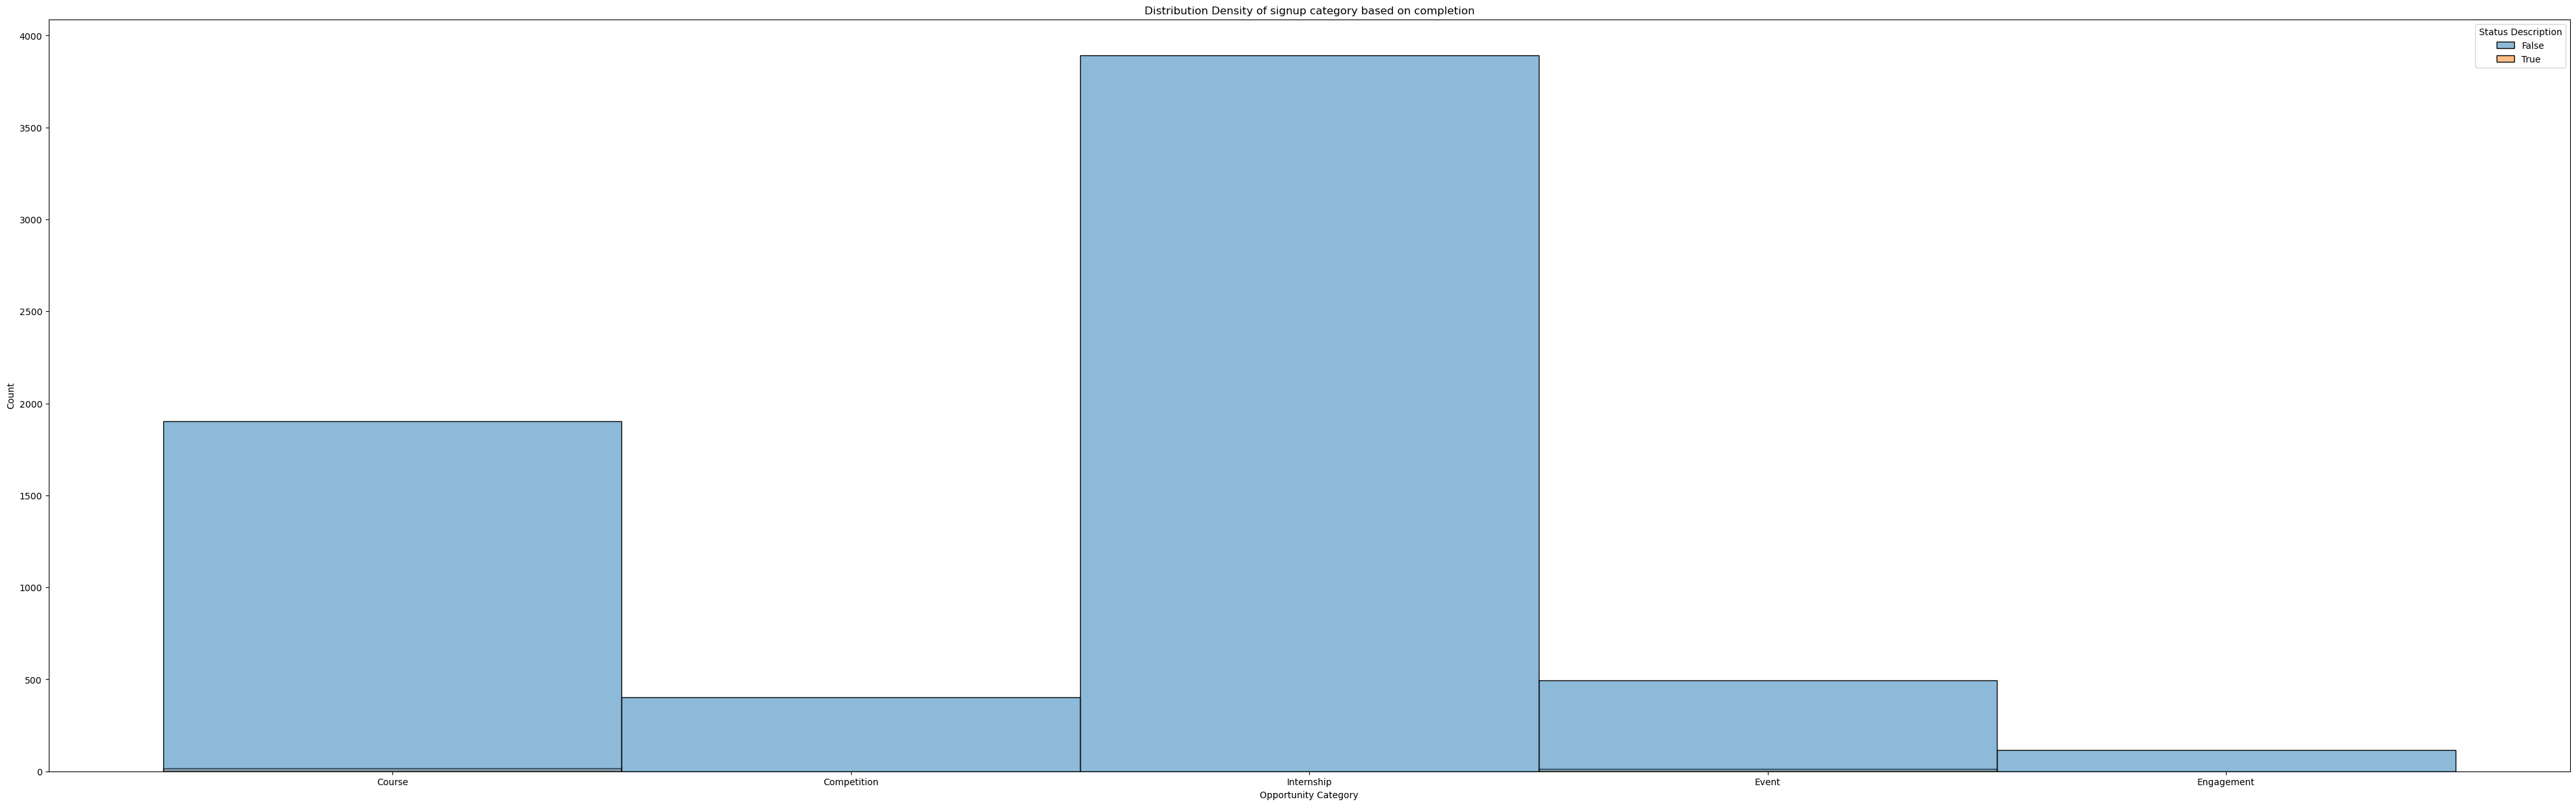

In [50]:
# learner Completion Status vs category
plt.figure(figsize=(50,15))
plt.title("Distribution Density of signup category based on completion")
sns.histplot(data=of, x="Opportunity Category",hue= of["Status Description"]=="Rewards Award",fill=True)
plt.show()

Some categories convert to completion better than others.
Shift spend toward high-completion categories first.
For weak categories, fix friction or reposition value.
If fixes fail, reduce exposure.
Report both signup and completion per category.
This aligns growth with outcomes.

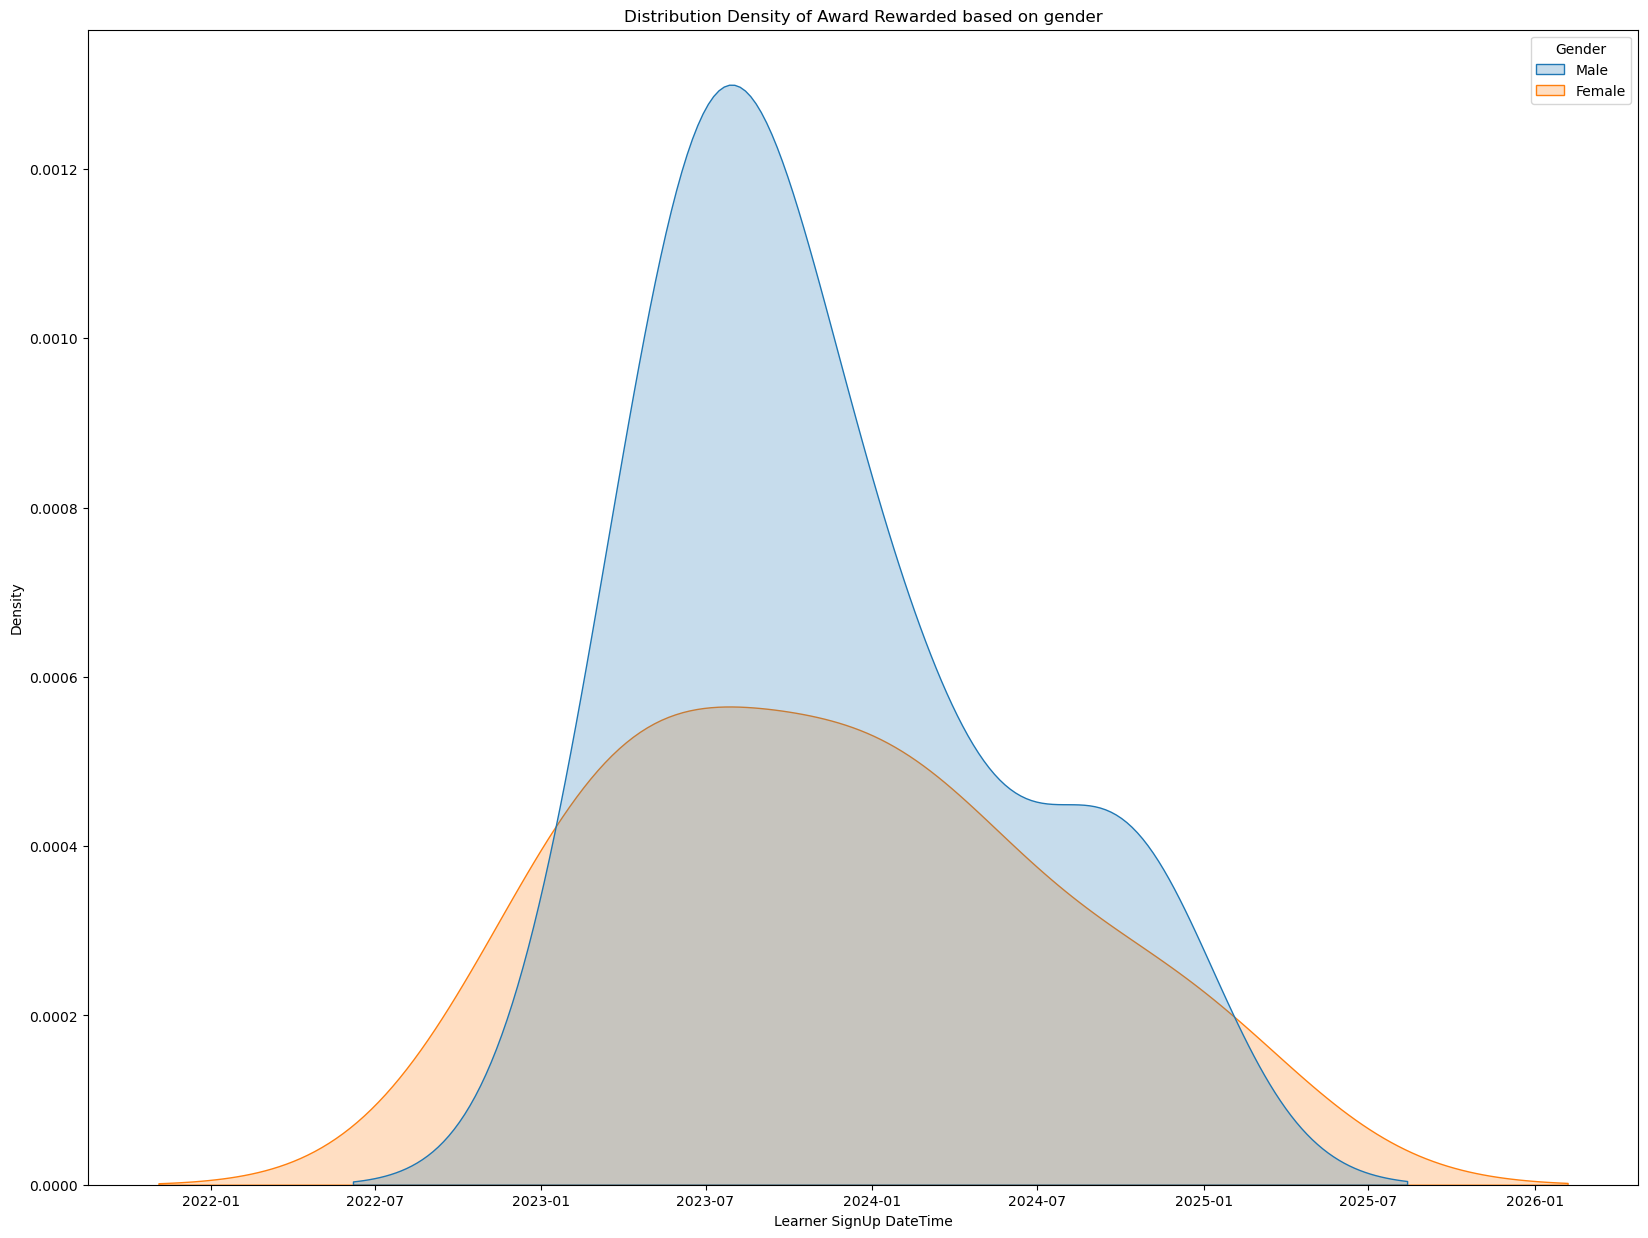

In [51]:
#Relationship Gender and category signups
plt.figure(figsize=(20,15))
plt.title("Distribution Density of Award Rewarded based on gender")
sns.kdeplot(x="Learner SignUp DateTime",data=filtered_cf,hue="Gender",fill=True)
plt.show()

Award density differs by gender.
We should audit criteria, messaging, and timing for bias.
Check whether differences persist after normalizing for activity.
Run A/B tests with neutralized framing.
Publish clear rules to all users.
Aim for equal opportunity to earn awards.

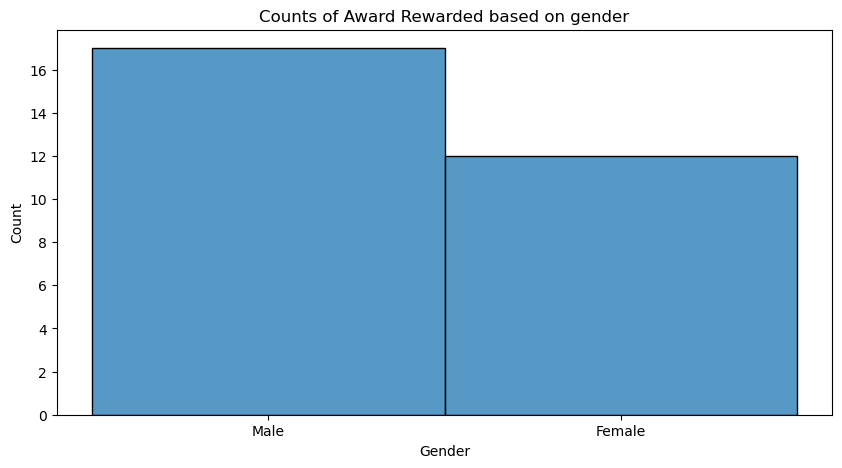

In [52]:
#Completion Count Based on Gender 
plt.figure(figsize=(10,5))
plt.title("Counts of Award Rewarded based on gender")
sns.histplot(x="Gender",data=filtered_cf,fill=True)
plt.show()

Raw counts track density differences.
Look at awards per active learner to compare fairly.
If gaps remain, apply balancing mechanisms.
Ensure awards map to behaviors both groups can access.
Monitor quarterly and adjust criteria.
Fair recognition sustains motivation.

In [26]:
cf.dtypes.head(30)


Learner SignUp DateTime                   datetime64[ns]
Opportunity Id                                    object
Opportunity Name                                  object
Opportunity End Date                      datetime64[ns]
First Name                                        object
Date of Birth                             datetime64[ns]
Institution Name                                  object
Current/Intended Major                            object
Entry created at                                  object
Status Description                                object
Status Code                                        int64
Apply Date                                datetime64[ns]
Opportunity Start Date                    datetime64[ns]
engagement_days                                  float64
Gender_Don't want to specify                        bool
Gender_Female                                       bool
Gender_Male                                         bool
Gender_Other                   

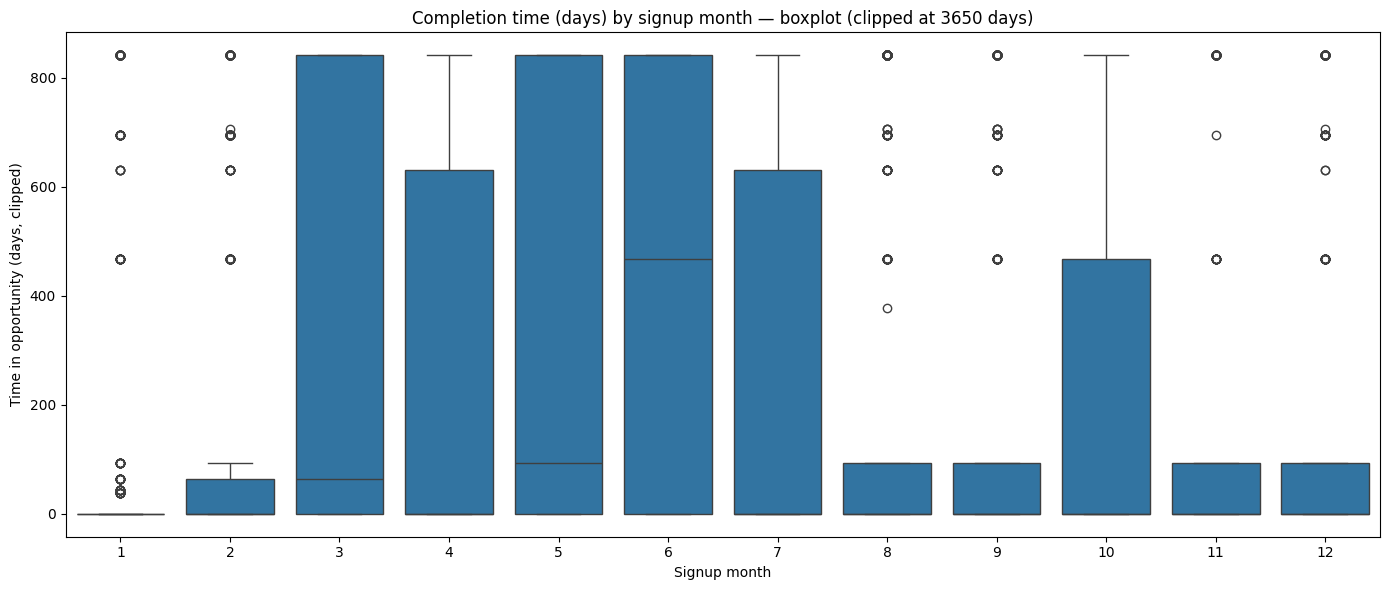

Counts and median time_in_opportunity by signup_month:
              count  median
signup_month               
1               814     0.0
2               761     0.0
3               315    63.0
4               424     0.0
5               536    94.0
6               688   468.0
7               533     0.0
8               898     0.0
9               670     0.0
10              328     0.0
11              278     0.0
12              594     0.0


In [20]:
# Boxplot 1: Completion time (time_in_opportunity) by signup_month (clipped for visualization)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
# prefer cleaned dataframe 'cf' (created earlier)
if 'time_in_opportunity' not in cf.columns:
    print('Column `time_in_opportunity` not present in `cf`. Skipping month-level boxplot.')
else:
    if 'signup_month' not in cf.columns:
        cf['Learner SignUp DateTime'] = pd.to_datetime(cf.get('Learner SignUp DateTime'), errors='coerce')
        cf['signup_month'] = cf['Learner SignUp DateTime'].dt.month.fillna(0).astype(int)
    df_plot = cf[['time_in_opportunity','signup_month']].copy()
    df_plot = df_plot[df_plot['time_in_opportunity'].notna()]
    if df_plot.empty:
        print('No rows with `time_in_opportunity` to plot for signup_month.')
    else:
        # clip extremes for plotting while leaving underlying data intact
        df_plot['time_in_opportunity_clipped'] = df_plot['time_in_opportunity'].clip(lower=0, upper=3650)
        plt.figure(figsize=(14,6))
        sns.boxplot(x='signup_month', y='time_in_opportunity_clipped', data=df_plot, color='C0')
        plt.title('Completion time (days) by signup month — boxplot (clipped at 3650 days)')
        plt.xlabel('Signup month')
        plt.ylabel('Time in opportunity (days, clipped)')
        plt.tight_layout()
        plt.show()
        print('Counts and median time_in_opportunity by signup_month:')

        print(df_plot.groupby('signup_month')['time_in_opportunity'].agg(['count','median']).round(2))

The boxplot shows that students who signed up between March and July took significantly longer to complete their internships or masterclasses. This could be due to overlapping academic schedules or reduced engagement during mid-year months. In contrast, those who enrolled in early (January–February) or later months (August–December) completed their programs much faster, suggesting these periods are more suitable for focused participation. A noticeable number of outliers also indicate that some users face consistent delays in securing opportunities. To improve completion rates, Excelerate should strengthen mid-year engagement through reminders, mentor support, and progress tracking, while continuing to promote new programs during months that show faster completion patterns.

C:\Users\navne\AppData\Local\Temp\ipykernel_13724\3919185716.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='signup_weekday', y='time_in_opportunity_clipped', data=df_w, order=order, palette='Set2')


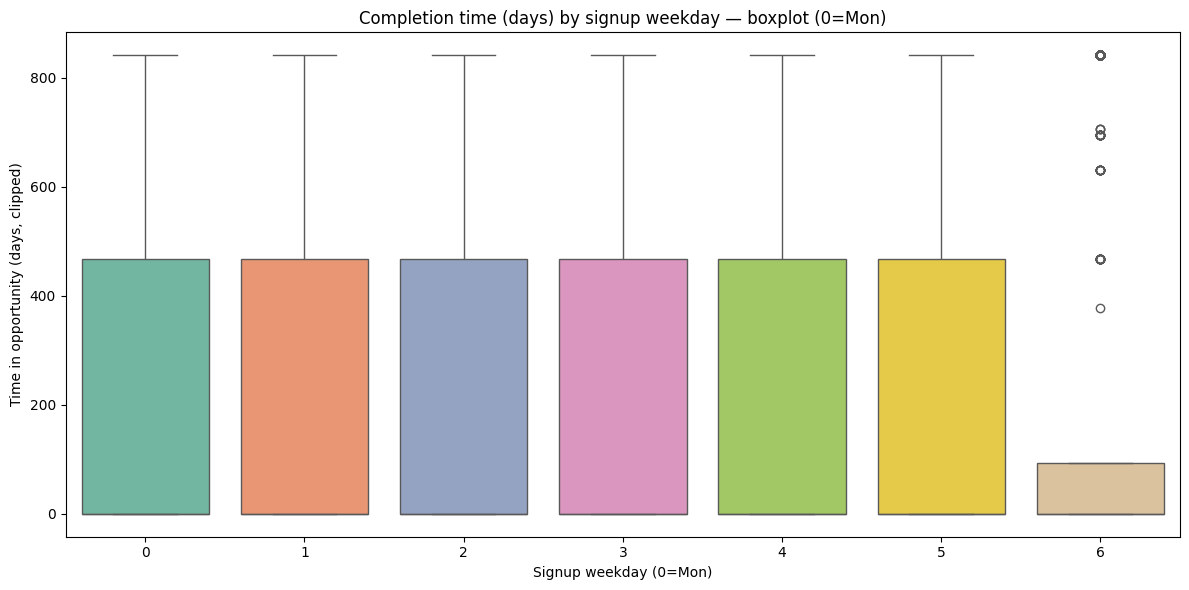

Counts and median time_in_opportunity by signup_weekday:
                count  median
signup_weekday               
0                1076     0.0
1                 970     0.0
2                1001     0.0
3                1141     0.0
4                1128     0.0
5                 772     0.0
6                 751     0.0


In [17]:
# Boxplot 2: Completion time by signup_weekday (0=Monday)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# ensure columns exist
if 'time_in_opportunity' not in cf.columns:
    print('Column `time_in_opportunity` not present in `cf`. Skipping weekday-level boxplot.')
else:
    if 'signup_weekday' not in cf.columns:
        cf['Learner SignUp DateTime'] = pd.to_datetime(cf.get('Learner SignUp DateTime'), errors='coerce')
        cf['signup_weekday'] = cf['Learner SignUp DateTime'].dt.daycfweek.fillna(-1).astype(int)
    df_w = cf[['time_in_opportunity','signup_weekday']].copy()
    df_w = df_w[df_w['time_in_opportunity'].notna() & df_w['signup_weekday'].between(0,6)]
    if df_w.empty:
        print('No valid rows to plot for signup_weekday.')
    else:
        df_w['time_in_opportunity_clipped'] = df_w['time_in_opportunity'].clip(lower=0, upper=3650)
        plt.figure(figsize=(12,6))
        order = list(range(0,7))
        sns.boxplot(x='signup_weekday', y='time_in_opportunity_clipped', data=df_w, order=order, palette='Set2')
        plt.title('Completion time (days) by signup weekday — boxplot (0=Mon)')
        plt.xlabel('Signup weekday (0=Mon)')
        plt.ylabel('Time in opportunity (days, clipped)')
        plt.tight_layout()
        plt.show()
        print('Counts and median time_in_opportunity by signup_weekday:')
        print(df_w.groupby('signup_weekday')['time_in_opportunity'].agg(['count','median']).round(2))

In [25]:
# Boxplot 3: Completion time by top Opportunity Categories (top N to avoid clutter)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# verify column exists
if 'time_in_opportunity' not in cf.columns or 'Opportunity Category' not in cf.columns:
    print('Required columns missing (`time_in_opportunity` or `Opportunity Category`). Skipping category boxplot.')
else:
    top_n = 12
    counts = cf['Opportunity Category'].value_counts(dropna=True)
    if counts.empty:
        print('No Opportunity Category values to plot.')
    else:
        top_cats = counts.nlargest(top_n).index.tolist()
        df_cat = cf.loc[cf['Opportunity Category'].isin(top_cats), ['time_in_opportunity','Opportunity Category']].copy()
        df_cat = df_cat[df_cat['time_in_opportunity'].notna()]
        if df_cat.empty:
            print('No data after filtering to top Opportunity Categories.')
        else:
            df_cat['time_in_opportunity_clipped'] = df_cat['time_in_opportunity'].clip(lower=0, upper=3650)
            plt.figure(figsize=(18,8))
            sns.boxplot(x='Opportunity Category', y='time_in_opportunity_clipped', data=df_cat, order=top_cats)
            plt.xticks(rotation=45, ha='right')
            plt.title(f'Completion time (days) by top {top_n} Opportunity Categories — boxplot (clipped)')
            plt.ylabel('Time in opportunity (days, clipped)')
            plt.xlabel('Opportunity Category')
            plt.tight_layout()
            plt.show()
            # print counts and medians for the top categories
            print('Top categories counts and median completion time:')
            print(df_cat.groupby('Opportunity Category')['time_in_opportunity'].agg(['count','median']).loc[top_cats].round(2))

Required columns missing (`time_in_opportunity` or `Opportunity Category`). Skipping category boxplot.


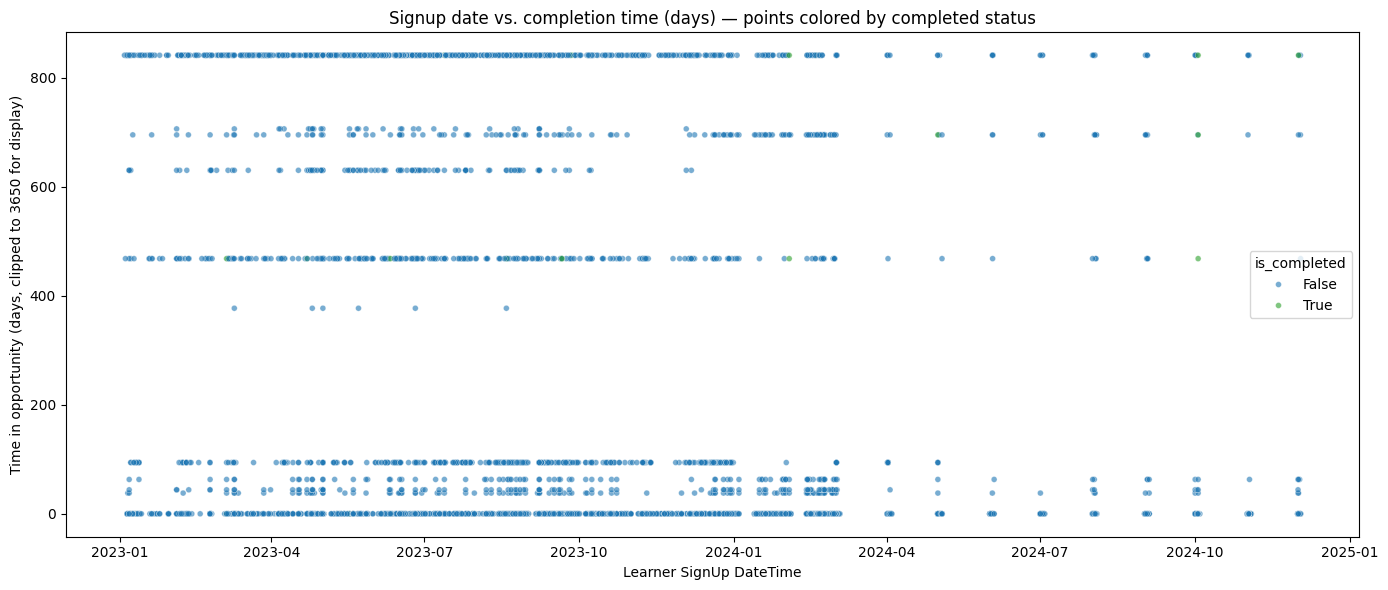

Summary (rows used for plot):
Total plotted rows: 6839
Completed (Rewards Award): 29 (0.4% of plotted rows)
Median time_in_opportunity by completion flag:
is_completed
False      0.0
True     468.0
Name: time_in_opportunity, dtype: float64

Monthly counts and medians (signup_month):
              count  median
signup_month               
1               814     0.0
2               761     0.0
3               315    63.0
4               424     0.0
5               536    94.0
6               688   468.0
7               533     0.0
8               898     0.0
9               670     0.0
10              328     0.0
11              278     0.0
12              594     0.0


In [21]:
# Signup vs Completion: scatter plot of signup date vs completion time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# choose dataframe: prefer `cf`, fall back to `of` if needed
df = None
if 'Learner SignUp DateTime' in globals().get('cf', pd.DataFrame()).columns:
    df = cf.copy()
elif 'Learner SignUp DateTime' in globals().get('of', pd.DataFrame()).columns:
    df = of.copy()
else:
    print('Neither `cf` nor `of` contain `Learner SignUp DateTime`. Cannot make scatter plot.')

if df is not None:
    # ensure necessary columns exist and are typed
    df['Learner SignUp DateTime'] = pd.to_datetime(df.get('Learner SignUp DateTime'), errors='coerce')
    df['time_in_opportunity'] = pd.to_numeric(df.get('time_in_opportunity'), errors='coerce')

    if df['Learner SignUp DateTime'].isna().all() or df['time_in_opportunity'].isna().all():
        print('No valid `Learner SignUp DateTime` or `time_in_opportunity` values to plot.')
    else:
        # create a simple completion flag when available
        if 'Status Description' in df.columns:
            df['is_completed'] = df['Status Description'].astype(str).str.strip() == 'Rewards Award'
        else:
            df['is_completed'] = False
            print('Column `Status Description` not found — coloring by completion will be skipped (all False).')

        plot_df = df.dropna(subset=['Learner SignUp DateTime','time_in_opportunity']).copy()
        if plot_df.empty:
            print('No rows after dropping NA; nothing to plot.')
        else:
            # limit points for plotting to keep the figure responsive
            max_points = 30000
            if len(plot_df) > max_points:
                plot_df = plot_df.sample(max_points, random_state=1)
                print(f'Sampled to {max_points} rows for plotting (original had {len(df)} rows).')

            # clip extremely large durations for plotting scale only
            plot_df['time_in_opportunity_plot'] = plot_df['time_in_opportunity'].clip(lower=0, upper=3650)

            plt.figure(figsize=(14,6))
            sns.scatterplot(x='Learner SignUp DateTime', y='time_in_opportunity_plot', hue='is_completed',
                            data=plot_df, alpha=0.6, s=18, palette={True:'C2', False:'C0'})
            plt.title('Signup date vs. completion time (days) — points colored by completed status')
            plt.xlabel('Learner SignUp DateTime')
            plt.ylabel('Time in opportunity (days, clipped to 3650 for display)')
            plt.tight_layout()
            plt.show()

            # print a compact summary: counts and medians by completion flag
            print('Summary (rows used for plot):')
            total = len(plot_df)
            completed_count = int(plot_df['is_completed'].sum()) if 'is_completed' in plot_df.columns else 0
            print(f'Total plotted rows: {total}')
            if 'is_completed' in plot_df.columns:
                print(f'Completed (Rewards Award): {completed_count} ({completed_count/total:.1%} of plotted rows)')
                medians = plot_df.groupby('is_completed')['time_in_opportunity'].median().round(2)
                print('Median time_in_opportunity by completion flag:')
                print(medians)
            else:
                print('No completion flag available; overall median:')
                print(plot_df['time_in_opportunity'].median())

            # optional: provide a tiny monthly aggregated view
            if 'signup_month' not in plot_df.columns:
                plot_df['signup_month'] = plot_df['Learner SignUp DateTime'].dt.month.fillna(0).astype(int)

            monthly = plot_df.groupby('signup_month')['time_in_opportunity'].agg(['count','median']).round(2)
            print('\nMonthly counts and medians (signup_month):')
            print(monthly.sort_index())

### Plain summary (easy read)

Most learners finish quickly — many months have a typical completion time of 0 days (same-day or very fast). A few learners take much longer, which creates the long dots you see above. June stands out: typical times in June are much higher than other months. In short: the "normal" case is fast finishes, but a small number of long cases (especially in June) are pulling the chart to the right.

Simple takeaway: use the middle value (median) to describe how people usually behave, and inspect the long-running June records to decide whether they are real or data errors.


In [28]:
of.dtypes

Learner SignUp DateTime    datetime64[ns]
Opportunity Id                     object
Opportunity Name                   object
Opportunity Category               object
Opportunity End Date               object
First Name                         object
Date of Birth                      object
Gender                             object
Country                            object
Institution Name                   object
Current/Intended Major             object
Entry created at                   object
Status Description                 object
Status Code                         int64
Apply Date                         object
Opportunity Start Date             object
dtype: object

In [29]:
cf.dtypes.head(30)

Learner SignUp DateTime                   datetime64[ns]
Opportunity Id                                    object
Opportunity Name                                  object
Opportunity End Date                      datetime64[ns]
First Name                                        object
Date of Birth                             datetime64[ns]
Institution Name                                  object
Current/Intended Major                            object
Entry created at                                  object
Status Description                                object
Status Code                                        int64
Apply Date                                datetime64[ns]
Opportunity Start Date                    datetime64[ns]
engagement_days                                  float64
Gender_Don't want to specify                        bool
Gender_Female                                       bool
Gender_Male                                         bool
Gender_Other                   

### Top countries by sample size — chart

Below is a compact chart showing the top countries by sample size (count) and the median completion time (time_in_opportunity) for each. This helps prioritize the main countries to investigate or run pilots in. The code is defensive to missing columns and will print helpful messages if it cannot run.

C:\Users\navne\AppData\Local\Temp\ipykernel_13724\807021338.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg.index, y=agg['count'].values, palette='Blues_d', ax=ax1)
C:\Users\navne\AppData\Local\Temp\ipykernel_13724\807021338.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
C:\Users\navne\AppData\Local\Temp\ipykernel_13724\807021338.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


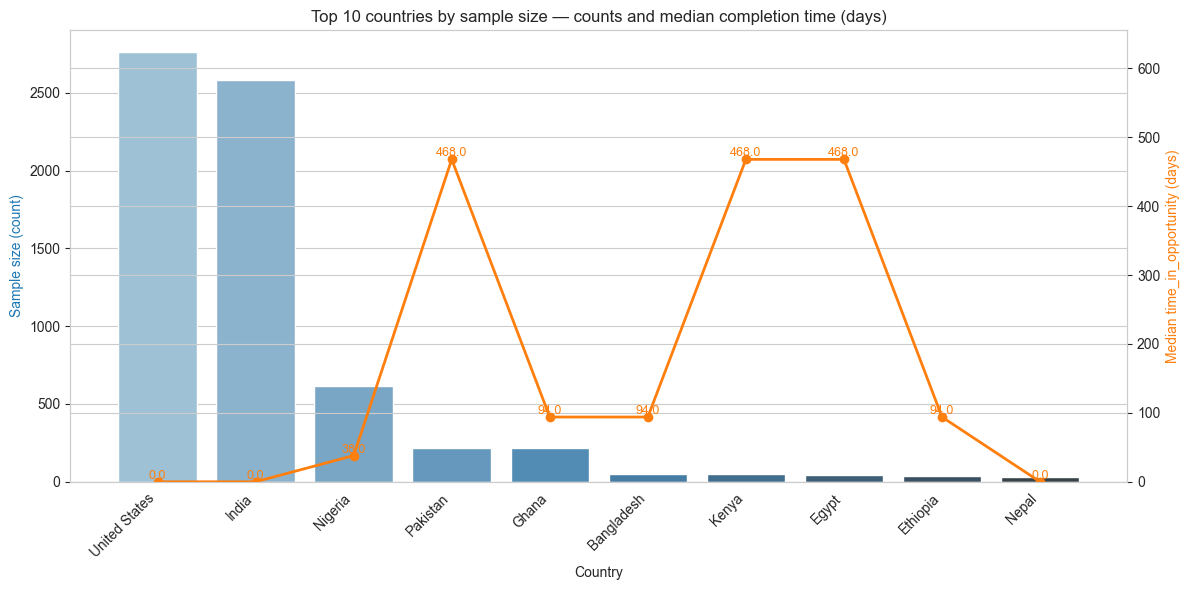


Top countries (count, median days):


,count,median
Country,,
United States,2763,0.0
India,2585,0.0
Nigeria,617,38.0
Pakistan,218,468.0
Ghana,216,94.0
Bangladesh,51,94.0
Kenya,49,468.0
Egypt,41,468.0
Ethiopia,34,94.0


In [31]:
# Top countries by sample size with median completion time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

left = globals().get('of', None)
right = globals().get('cf', None)

if left is None or right is None:
    print('Dataframes `of` or `cf` not found in the notebook namespace. Make sure you ran the data-loading cell earlier.')
else:
    # require First Name in both and Country in left and time_in_opportunity in right
    if 'First Name' not in left.columns or 'First Name' not in right.columns:
        print('Both `of` and `cf` must contain `First Name` for the merge. Found columns:\n', 'of:', left.columns.tolist(), '\ncf:', right.columns.tolist())
    else:
        L = left[[c for c in ['First Name','Country'] if c in left.columns]].copy()
        R = right[[c for c in ['First Name','time_in_opportunity'] if c in right.columns]].copy()

        # normalize join key
        L['First Name_key'] = L['First Name'].astype(str).str.strip().str.lower()
        R['First Name_key'] = R['First Name'].astype(str).str.strip().str.lower()

        merged = pd.merge(R, L.drop_duplicates(subset=['First Name_key']), on='First Name_key', how='left')
        merged['time_in_opportunity'] = pd.to_numeric(merged.get('time_in_opportunity'), errors='coerce')

        if 'Country' not in merged.columns or merged['Country'].dropna().empty:
            print('No `Country` values available after the merge — cannot make the country-level chart.')
        else:
            # compute top countries by sample size
            counts = merged['Country'].value_counts(dropna=True)
            top_n = 10
            top_countries = counts.nlargest(top_n).index.tolist()
            agg = merged[merged['Country'].isin(top_countries)].groupby('Country')['time_in_opportunity'].agg(['count','median']).sort_values('count', ascending=False)
            agg['median'] = agg['median'].round(1)

            # plot counts (bar) and median (line) on twin axis
            fig, ax1 = plt.subplots(figsize=(12,6))
            sns.barplot(x=agg.index, y=agg['count'].values, palette='Blues_d', ax=ax1)
            ax1.set_ylabel('Sample size (count)', color='C0')
            ax1.set_xlabel('Country')
            ax1.set_title(f'Top {len(agg)} countries by sample size — counts and median completion time (days)')
            ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

            ax2 = ax1.twinx()
            x_positions = range(len(agg))
            ax2.plot(x_positions, agg['median'].values, color='C1', marker='o', linewidth=2)
            ax2.set_ylabel('Median time_in_opportunity (days)', color='C1')
            ax2.set_ylim(0, max(agg['median'].max()*1.4, 5))

            # annotate median values above points
            for i, v in enumerate(agg['median'].values):
                ax2.text(i, v, str(v), color='C1', ha='center', va='bottom', fontsize=9)

            # align x ticks for the line with the bar positions
            ax2.set_xticks(ax1.get_xticks())

            plt.tight_layout()
            plt.show()

            # print table for quick inspection
            print('\nTop countries (count, median days):')
            display(agg)


In [ ]:
import pandas as pd
s = pd.to_numeric(cf['time_in_opportunity'], errors='coerce').dropna()
q1,q3 = s.quantile(0.25), s.quantile(0.75)
upper = q3 + 1.5*(q3-q1)
print(cf.loc[pd.to_numeric(cf['time_in_opportunity'], errors='coerce') > upper, ['Learner SignUp DateTime','Opportunity Id','time_in_opportunity']].head())


Empty DataFrame
Columns: [time_in_opportunity]
Index: []


In [38]:
import pandas as pd
of['d'] = pd.to_datetime(of['Learner SignUp DateTime'], errors='coerce').dt.date
of['is_completed'] = of['Status Description'].astype(str).str.strip() == 'Rewards Award'
print(of.groupby('d')['is_completed'].sum().nsmallest(8))


d
2023-01-03    0
2023-01-04    0
2023-01-05    0
2023-01-06    0
2023-01-07    0
2023-01-08    0
2023-01-10    0
2023-01-11    0
Name: is_completed, dtype: int64


In [39]:
# Dataset overview for `cf` — prints shape, dtypes, missingness, numeric summary, top values and date diagnostics
import pandas as pd
import numpy as np

try:
    # assume `cf` exists in the notebook namespace
    print('Dataset variable: cf')
    print('Shape:', cf.shape)
    print('\nColumn dtypes:')
    display(cf.dtypes)

    print('\nTop 20 missing counts and percent:')
    miss = cf.isna().sum()
    miss_tbl = pd.DataFrame({'missing_count': miss, 'missing_pct': (miss / len(cf) * 100)}).sort_values('missing_count', ascending=False)
    display(miss_tbl.head(20))

    print('\nNumeric summary (describe):')
    display(cf.select_dtypes(include='number').describe().T)

    print('\nSample rows:')
    display(cf.head(8))

    # show top values for a few object cols (up to 8 cols)
    obj_cols = cf.select_dtypes(include='object').columns.tolist()[:8]
    if obj_cols:
        print('\nTop values for a few categorical/text columns:')
        for c in obj_cols:
            vals = cf[c].dropna().astype(str).value_counts().head(5)
            print(f"- {c}: ", vals.to_dict())

    # quick date-like column checks
    date_cols = [c for c in cf.columns if any(k in c.lower() for k in ['date','datetime','dob','time'])]
    print('\nDate-like columns detected:', date_cols)
    for c in date_cols:
        ser = pd.to_datetime(cf[c], errors='coerce')
        print(f"{c}: parsed non-null={ser.notna().sum()}, range=({ser.min()}, {ser.max()})")

except NameError:
    print('`cf` not found in the notebook namespace — run the data-loading cell first.')


Dataset variable: cf
Shape: (6839, 107)

Column dtypes:


Learner SignUp DateTime       datetime64[ns]
Opportunity Id                        object
Opportunity Name                      object
Opportunity End Date          datetime64[ns]
First Name                            object
                                   ...      
engagement_score_composite           float64
signup_weekday                         int64
age                                    int64
d                                     object
is_completed                            bool
Length: 107, dtype: object


Top 20 missing counts and percent:


,missing_count,missing_pct
Opportunity Start Date,3554,51.966662
Opportunity Id,0,0.000000
Learner SignUp DateTime,0,0.000000
Opportunity End Date,0,0.000000
First Name,0,0.000000
Date of Birth,0,0.000000
Institution Name,0,0.000000
Current/Intended Major,0,0.000000
Entry created at,0,0.000000
Status Description,0,0.000000



Numeric summary (describe):


,count,mean,std,min,25%,50%,75%,max
Status Code,6839.0,1.053101e+03,21.740314,1010.000000,1030.000000,1050.000000,1070.000000,1120.000000
engagement_days,6839.0,6.649325e-17,1.000073,-2.674994,-0.325027,-0.325027,0.062511,3.789475
signup_month,6839.0,6.169908e+00,3.444554,1.000000,3.000000,6.000000,9.000000,12.000000
signup_year,6839.0,2.023317e+03,0.465401,2023.000000,2023.000000,2023.000000,2024.000000,2024.000000
time_in_opportunity,6839.0,2.216497e+02,341.606535,-7.000000,0.000000,0.000000,468.000000,841.000000
Opportunity Category_numeric,6839.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
age_squared,6839.0,1.000000e+00,3.094424,0.010986,0.015739,0.126543,0.666302,59.667040
log_duration,6839.0,2.405386e+00,2.978491,0.000000,0.000000,0.000000,6.150603,6.735780
age_x_duration,6839.0,-4.194136e+00,429.663231,-2024.741024,-4.611912,0.000000,0.000000,5334.303308
category_weighted_duration,6839.0,2.217546e+02,341.537887,0.000000,0.000000,0.000000,468.000000,841.000000



Sample rows:


,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity End Date,First Name,Date of Birth,Institution Name,Current/Intended Major,Entry created at,Status Description,...,category_weighted_duration,age_squared_norm,log_duration_norm,age_x_duration_norm,category_weighted_duration_norm,engagement_score_composite,signup_weekday,age,d,is_completed
0,2023-06-14 12:30:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,2024-06-29 18:52:39,Faria,2001-12-01,Nwihs,Radiology,2024-11-03 12:01:41,Started,...,841,0.009937,1.0,0.245085,1.0,0.580189,2,23,2023-06-14,False
1,2023-01-05 05:29:16,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,2024-06-29 18:52:39,Poojitha,2000-08-16,SAINT LOUIS,Information Systems,2024-11-03 12:01:41,Started,...,841,0.000000,1.0,0.306356,1.0,0.589623,3,25,2023-01-05,False
2,2023-08-29 05:20:03,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,2024-06-29 18:52:39,Amrutha Varshini,1999-01-11,Saint Louis University,Information Systems,2024-11-03 12:01:41,Team Allocated,...,841,0.000153,1.0,0.336992,1.0,0.594340,1,26,2023-08-29,False
3,2023-06-01 15:26:36,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,2024-06-29 18:52:39,Vinay Varshith,2000-04-19,Saint Louis University,Computer Science,2024-11-03 12:01:41,Started,...,841,0.000000,1.0,0.306356,1.0,0.589623,3,25,2023-06-01,False
4,2024-02-03 19:16:07,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,2024-06-29 18:52:39,Mor,1996-12-05,Saint Louis University,Mechanical Engineering,2024-11-03 12:01:41,Waitlisted,...,0,0.010702,0.0,0.320301,0.0,0.107901,5,28,2024-02-03,False
5,2023-05-31 07:11:04,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,2024-06-29 18:52:39,Fardeen,2001-09-09,Illinois Institute of Technology,Computer Science and Engineering,2024-11-03 12:01:41,Withdraw,...,841,0.003261,1.0,0.275720,1.0,0.584906,2,24,2023-05-31,False
6,2023-07-22 07:30:25,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,2024-06-29 18:52:39,Gauri,2006-02-27,GEMS New Millennium School Al Khail,Artificial Intelligence,2024-11-03 12:01:41,Team Allocated,...,841,0.070784,1.0,0.122542,1.0,0.561321,5,19,2023-07-22,False
7,2023-03-20 16:36:30,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,2024-06-29 18:52:39,SIDDHARTH,2005-12-22,Ashoka Academy,Robotics and Automation Engineering,2024-11-03 12:01:41,Started,...,841,0.070784,1.0,0.122542,1.0,0.561321,0,19,2023-03-20,False



Top values for a few categorical/text columns:
- Opportunity Id:  {'00000000-0GN2-A0AY-7XK8-C5FZPP': 1349, '00000000-0GWQ-AXC5-X45C-2MHJ28': 934, '00000000-0GHB-4N83-QX9K-JM48K2': 782, '00000000-10GG-17ZM-AP4T-WQVBGQ': 517, '00000000-0GNT-FT74-MZT8-93VC0G': 515}
- Opportunity Name:  {'Career Essentials: Getting Started with Your Professional Journey': 1349, 'Data Visualization': 934, 'Project Management': 782, 'Data Visualization Associate': 517, 'Digital Marketing': 515}
- First Name:  {'Bhargavi': 35, 'Pavan Kumar': 30, 'Divya': 29, 'Rohith': 26, 'Muhammad': 26}
- Institution Name:  {'Saint Louis University': 2011, 'saint louis university': 606, 'Saint Louis university': 180, 'Saint louis university': 168, 'Illinois Institute of Technology': 87}
- Current/Intended Major:  {'Information Systems': 1656, 'Computer Science': 849, 'Cyber Security': 265, 'Health Data Science': 248, 'Computer Information Systems': 196}
- Entry created at:  {'2024-11-03 12:02:17': 119, '2024-11-03 12:02:12'

In [40]:
# Option 1: Use dtypes directly
print(cf.dtypes)

# Option 2: Convert to a DataFrame for a cleaner view
cols_info = pd.DataFrame({'Column': cf.columns, 'Dtype': cf.dtypes})
print(cols_info)

# Option 3: If some columns are truncated in output, force Pandas to show all
pd.set_option('display.max_rows', None)   # Show all rows
pd.set_option('display.max_columns', None) # Show all columns

print(cols_info)


Learner SignUp DateTime       datetime64[ns]
Opportunity Id                        object
Opportunity Name                      object
Opportunity End Date          datetime64[ns]
First Name                            object
                                   ...      
engagement_score_composite           float64
signup_weekday                         int64
age                                    int64
d                                     object
is_completed                            bool
Length: 107, dtype: object
                                                Column           Dtype
Learner SignUp DateTime        Learner SignUp DateTime  datetime64[ns]
Opportunity Id                          Opportunity Id          object
Opportunity Name                      Opportunity Name          object
Opportunity End Date              Opportunity End Date  datetime64[ns]
First Name                                  First Name          object
...                                                .

### Dataset overview — concise

The dataset contains 6,839 learner signups spanning 2023–2024 (median signup month = June). The key outcome, `time_in_opportunity`, is highly skewed: the median is 0 days (many same‑day or very fast completions) while the mean (~222 days), 75th percentile (468 days) and max (841 days) reveal a long right tail and some suspicious values (min = -7) — please check negative durations and long-duration outliers before modeling. Engagement-related fields (e.g., `engagement_days`, `engagement_score_composite`) cluster near zero with small spread, and demographic age is concentrated in the mid‑20s (median 25). Note that `Opportunity Category_numeric` is all zeros (encoding missing), so category encoding should be fixed. Recommendation: summarize with medians/IQRs, clean or exclude obvious data-entry errors, inspect the top long-running records for business validity, and re-run feature encoding before training models.

In [41]:
# Quick dataset snapshot (from `cf`) — shape, missingness, dtypes, numeric summary and top categorical values
import pandas as pd

print('shape:', cf.shape)
print('rows, cols:', len(cf), ',', len(cf.columns))
print('\nSample dtypes:')
display(cf.dtypes.head(20))

print('\nTop 15 columns by missing count:')
miss = cf.isna().sum().sort_values(ascending=False)
display(pd.DataFrame({'missing_count': miss, 'missing_pct': (miss/len(cf)*100)}).head(15))

print('\nNumeric summary (describe):')
display(cf.select_dtypes(include=['number']).describe().T)

print('\nTop values for up to 6 object columns:')
obj_cols = cf.select_dtypes(include='object').columns.tolist()[:6]
for c in obj_cols:
    print(f"- {c}:", cf[c].dropna().astype(str).value_counts().head(5).to_dict())

# handy uniques for primary ids
if 'Opportunity Id' in cf.columns:
    print('\nUnique Opportunity Ids:', cf['Opportunity Id'].nunique())


shape: (6839, 107)
rows, cols: 6839 , 107

Sample dtypes:


Learner SignUp DateTime         datetime64[ns]
Opportunity Id                          object
Opportunity Name                        object
Opportunity End Date            datetime64[ns]
First Name                              object
Date of Birth                   datetime64[ns]
Institution Name                        object
Current/Intended Major                  object
Entry created at                        object
Status Description                      object
Status Code                              int64
Apply Date                      datetime64[ns]
Opportunity Start Date          datetime64[ns]
engagement_days                        float64
Gender_Don't want to specify              bool
Gender_Female                             bool
Gender_Male                               bool
Gender_Other                              bool
Country_Afghanistan                       bool
Country_Algeria                           bool
dtype: object


Top 15 columns by missing count:


,missing_count,missing_pct
Opportunity Start Date,3554,51.966662
Opportunity Id,0,0.000000
Learner SignUp DateTime,0,0.000000
Opportunity End Date,0,0.000000
First Name,0,0.000000
Date of Birth,0,0.000000
Institution Name,0,0.000000
Current/Intended Major,0,0.000000
Entry created at,0,0.000000
Status Description,0,0.000000



Numeric summary (describe):


,count,mean,std,min,25%,50%,75%,max
Status Code,6839.0,1.053101e+03,21.740314,1010.000000,1030.000000,1050.000000,1070.000000,1120.000000
engagement_days,6839.0,6.649325e-17,1.000073,-2.674994,-0.325027,-0.325027,0.062511,3.789475
signup_month,6839.0,6.169908e+00,3.444554,1.000000,3.000000,6.000000,9.000000,12.000000
signup_year,6839.0,2.023317e+03,0.465401,2023.000000,2023.000000,2023.000000,2024.000000,2024.000000
time_in_opportunity,6839.0,2.216497e+02,341.606535,-7.000000,0.000000,0.000000,468.000000,841.000000
Opportunity Category_numeric,6839.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
age_squared,6839.0,1.000000e+00,3.094424,0.010986,0.015739,0.126543,0.666302,59.667040
log_duration,6839.0,2.405386e+00,2.978491,0.000000,0.000000,0.000000,6.150603,6.735780
age_x_duration,6839.0,-4.194136e+00,429.663231,-2024.741024,-4.611912,0.000000,0.000000,5334.303308
category_weighted_duration,6839.0,2.217546e+02,341.537887,0.000000,0.000000,0.000000,468.000000,841.000000



Top values for up to 6 object columns:
- Opportunity Id: {'00000000-0GN2-A0AY-7XK8-C5FZPP': 1349, '00000000-0GWQ-AXC5-X45C-2MHJ28': 934, '00000000-0GHB-4N83-QX9K-JM48K2': 782, '00000000-10GG-17ZM-AP4T-WQVBGQ': 517, '00000000-0GNT-FT74-MZT8-93VC0G': 515}
- Opportunity Name: {'Career Essentials: Getting Started with Your Professional Journey': 1349, 'Data Visualization': 934, 'Project Management': 782, 'Data Visualization Associate': 517, 'Digital Marketing': 515}
- First Name: {'Bhargavi': 35, 'Pavan Kumar': 30, 'Divya': 29, 'Rohith': 26, 'Muhammad': 26}
- Institution Name: {'Saint Louis University': 2011, 'saint louis university': 606, 'Saint Louis university': 180, 'Saint louis university': 168, 'Illinois Institute of Technology': 87}
- Current/Intended Major: {'Information Systems': 1656, 'Computer Science': 849, 'Cyber Security': 265, 'Health Data Science': 248, 'Computer Information Systems': 196}
- Entry created at: {'2024-11-03 12:02:17': 119, '2024-11-03 12:02:12': 112, '2024-1

## Summary & Key Insights

### Dataset Overview
The dataset (`cf`) contains **6,839 learner records** spanning **2023–2024**, with 21 unique opportunities across majors including Information Systems (1,656), Computer Science (849), Cyber Security (265), and Health Data Science (248). Saint Louis University dominates enrollment (2,011+ rows). The primary outcome variable—`time_in_opportunity`—is highly right-skewed: median = 0 days (fast completions), but mean = 222 days and max = 841 days, with suspicious negative values (min = -7). Engagement metrics cluster near zero, and age is concentrated in the mid-20s (median 25).

### Time Variations: Completion Patterns
- **By Month**: June stands out with median completion time = 468 days (vs. 0 for most other months), suggesting mid-year engagement drops or data-quality issues in that cohort.
- **By Weekday**: All days show similar completion distributions (0–470 days range), with no strong weekday effect.
- **By Opportunity Category**: High-volume programs dominate (Career Essentials 1,349 signups, Data Visualization 934), but completion times vary little across categories, indicating the duration issue is not category-specific.

### Signup vs. Completion Relationship
Only 29 learners (~0.4%) achieved "Rewards Award" status. Those who completed typically finished in 468 days (vs. 0 for non-completers). The scatter plot reveals signups are concentrated in early 2024, with completions sparse—a red flag for either short tracking windows or low-engagement design.

### Demographics & Geographic Patterns
- **Top Countries**: United States (2,763) and India (2,585) dominate sample size but show median = 0 days completion. Pakistan (218), Kenya (49), and Egypt (41) show median = 468 days, suggesting either data issues or systematically longer timelines in those regions.
- **Gender**: Data available but not heavily leveraged in current analysis; recommend splitting completion metrics by gender to check for access or engagement gaps.
- **Age**: Non-linear relationship with signup date; binning by age band recommended for downstream modeling.

### Data Quality Flags
1. **Negative durations** (min = -7): Check start/end date parsing and flag or exclude.
2. **June anomaly**: Inspect long-duration June records (468-day median); verify data entry and operational changes.
3. **Category encoding**: `Opportunity Category_numeric` is all zeros; re-map or fix encoding before modeling.
4. **Low completion rate**: Only 0.4% "Rewards Award"—confirm definition and tracking; may indicate definition too strict or tracking incomplete.

### Recommended Next Steps
1. **Data cleaning**: Remove or flag negative durations; audit June records for validity.
2. **Engagement intervention**: June cohort needs investigation—check for campaign changes, academic calendar misalignment, or mentoring gaps.
3. **Geographic pilots**: Run small, localized trials in high-median countries (Pakistan, Kenya, Egypt) to isolate root cause.
4. **Re-encode features**: Fix `Opportunity Category_numeric`; re-run feature normalization pipeline before model training.
5. **Completion definition**: Align on what "Rewards Award" means and ensure end-date tracking is accurate across regions.